## 1 - Importing necessary libraries

In [256]:
import sys
import os

# Adicionar o caminho pai ao sys.path
sys.path.insert(0, os.path.abspath('..'))

from commons.utils import barplot_column
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from dotenv import load_dotenv 

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

%matplotlib inline


### 1.1 - Supporting Functions

In [257]:
def apply_ohe(df, col, prefix):
    """
    Apply one-hot encoding to a semicolon-separated column in the dataframe.
    
    Parameters:
    df (pd.DataFrame): The input dataframe.
    col (str): The column name to be one-hot encoded.
    prefix (str): The prefix for the new one-hot encoded columns.
    
    Returns:
    pd.DataFrame: DataFrame with one-hot encoded columns added.
    """
    # Ensure no NaNs and normalize separators/whitespace
    df[col] = df[col].fillna('').astype(str)
    cleaned = df[col].str.replace(r'\s*;\s*', ';', regex=True).str.strip(';')
    
    # Create multi-hot / one-hot columns and prefix them for clarity
    ohe = cleaned.str.get_dummies(sep=';').add_prefix(prefix)
    
    # Attach the one-hot columns to the original dataframe
    df = pd.concat([df, ohe], axis=1)
    
    return df

In [258]:
def analysis_column(df, col):
    """
    Analyze a specific column in the dataframe, providing dataframe of value counts and printing basic statistics
    
    Parameters:
    df (pd.DataFrame): The input dataframe.
    col (str): The column name to be analyzed.

    Returns:
    pd.DataFrame: DataFrame containing value counts for the specified column with the index reset.
    """
    value_counts = df[col].value_counts(dropna=False).reset_index()
    value_counts.columns = [col, 'count']
    print(f"Analysis of column: {col}")
    print(f"Total unique values: {df[col].nunique(dropna=False)}")
    print(f"Number of missing values: {df[col].isnull().sum()}")
    print(f"Most frequent value: {df[col].mode()[0]} (Count: {df[col].value_counts().max()})")
    return value_counts

In [259]:
def normalize_column(df, column, type='MinMaxScaler'):
    # Create a sample pandas Series
    s = df[column]

    # Sklearn expects a 2D array, so we reshape the Series
    s_array = s.values.reshape(-1, 1)
    
    # Initialize the scaler and fit/transform the data
    if type=='MinMaxScaler':
        scaler = MinMaxScaler()
    s_normalized = scaler.fit_transform(s_array)

    # Convert the resulting numpy array back to a pandas Series
    print(f"\nNormalized Series (Scikit-Learn {type}):")
    print(s_normalized.flatten())
    df[column] = s_normalized.flatten()
    return df

## 2 - Loading Data

In [260]:
load_dotenv()
LOCAL_PATH = os.getenv("LOCAL_PATH")

In [261]:
path_results_public = "survey_results_public.csv"
path_results_schema = "survey_results_schema.csv"
path_minimum_wage = "minimum-wage-by-country-2025.json"
path_gdp = "gdp-per-capita-by-country-2025.json"

In [262]:
df_res_pub = pd.read_csv(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_results_public}")

In [263]:

df_res_sch = pd.read_csv(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_results_schema}")

Extra Information Sources:
- <a href="https://worldpopulationreview.com/country-rankings/minimum-wage-by-country">Minimum Wage by Country<a>
- <a href="https://worldpopulationreview.com/country-rankings/gdp-per-capita-by-country">Country GDP<a>

In [264]:
df_minimum_wage = pd.read_json(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_minimum_wage}")
df_minimum_wage.columns = ["flagCode", "Country", "MinimumWageHourly", "MinimumWageAnnual"]

In [265]:
df_country_gdp = pd.read_json(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_gdp}")

In [266]:
# Treating df_country_gdp, create column with gdp per capita information prioritizing most up-to-date information
df_country_gdp.drop("flagCode", axis=1, inplace=True)
df_country_gdp.columns = ['country', 'gdp_imf_2025', 'gdp_un_2023']
df_country_gdp['gdp_per_capita'] = df_country_gdp['gdp_imf_2025']
index_null = df_country_gdp['gdp_per_capita'].isnull()
df_country_gdp.loc[index_null, 'gdp_per_capita'] = df_country_gdp['gdp_un_2023']
df_country_gdp = df_country_gdp[['country', 'gdp_per_capita']]

In [267]:
# Create column "most_gdp_pc" ordering by gdp_per_capita where the poorest country is 0 and the richest is the last one.
df_country_gdp = df_country_gdp.sort_values(['gdp_per_capita'], ascending=True).reset_index(drop=True).reset_index()
df_country_gdp.columns = ['most_gdp_pc', 'country', 'gdp_per_capita']

In [268]:
df_country_gdp

,most_gdp_pc,country,gdp_per_capita
0,0,Burundi,156.50
1,1,South Sudan,334.14
2,2,Afghanistan,396.02
3,3,Malawi,448.29
4,4,Yemen,455.46
...,...,...,...
204,204,Switzerland,111716.02
205,205,Bermuda,125841.60
206,206,Luxembourg,141079.52
207,207,Liechtenstein,201150.46


## 3 - Exploratory Data Analysis

The data file for the 2025 Stack Overflow Developer Survey contains numerous columns, each corresponding to a specific survey question or a calculated metric. 
While the exact column names is 170, they generally fall into categories such as: 

**Core Identifiers and Demographics**
- ResponseId: A unique identifier for each respondent.
- Q[Number] (e.g., Q120): Raw question identifiers which are used internally in the dataset, but usually accompanied by a schema file that maps them to the actual question text.
- MainBranch: The primary professional role of the respondent (e.g., "Developer by profession").
- Age: The age group of the developer (e.g., 18-24, 25-34).
- Employment: Employment status (e.g., full-time, part-time, student).
- Country: The country where the respondent resides.
- EdLevel: The highest level of formal education attained.
- RemoteWork: Working situation (e.g., fully remote, hybrid, in-person). 

**Technology Usage and Preference**
- LanguageHaveWorkedWith/WantToWorkWith: The programming, scripting, and markup languages the developer has worked with in the past year or wants to learn, with responses often separated by semicolons.
- DatabaseHaveWorkedWith/WantToWorkWith: Similarly, the databases the developer uses or plans to use (e.g., PostgreSQL, MySQL, MongoDB).
- PlatformHaveWorkedWith/WantToWorkWith: Development platforms (e.g., Android, AWS, Docker).
- WebframeHaveWorkedWith/WantToWorkWith: Web frameworks (e.g., React, Vue.js, Django).
- ToolsTechHaveWorkedWith/WantToWorkWith: Other development tools and technologies.
- OpSys: The primary operating system used. 

**AI Tools and Usage**
- AI columns*: A new focus for the 2025 survey, these columns capture usage, sentiment, and trust regarding AI tools and agents.
- AIAgent: Whether the developer uses AI agents at work and how frequently (daily, weekly, etc.).
- AIToolsSentiment: The developer's general feeling about AI tools (favorable, indifferent, unfavorable).
- AIIncreasedProductivity: The perceived impact of AI tools on personal or team productivity. 

**Professional and Personal Details**- 
- YearsCode: The total number of years the respondent has been coding.
- DevType: The specific developer roles held (e.g., full-stack, back-end, mobile, architect).
- Salary: Information related to compensation, often with conversions to USD for easier analysis.
- JobSat: Job satisfaction level (e.g., Very satisfied, Slightly dissatisfied).
- LearnCode: Methods used to learn coding (e.g., online courses, books, self-taught).

In [269]:
df_res_sch[df_res_sch['qname']=='LanguageAdmired']

,qid,qname,question,type,sub,sq_id


In [270]:
df_res_pub['LanguageAdmired']

0                                            Dart
1                                            Java
2             Dart;HTML/CSS;JavaScript;TypeScript
3                                     Java;Kotlin
4        C#;Java;JavaScript;Python;SQL;TypeScript
                           ...                   
49118                                         NaN
49119                                         NaN
49120                                         NaN
49121                                      C#;SQL
49122                                         NaN
Name: LanguageAdmired, Length: 49123, dtype: object

In [271]:
df_res_pub['LanguageHaveWorkedWith']

0                         Bash/Shell (all shells);Dart;SQL
1                                                     Java
2                      Dart;HTML/CSS;JavaScript;TypeScript
3                                          Java;Kotlin;SQL
4        C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...
                               ...                        
49118                                                  NaN
49119                                                  NaN
49120                                                  NaN
49121                                               C#;SQL
49122                                                  NaN
Name: LanguageHaveWorkedWith, Length: 49123, dtype: object

In [272]:
df_res_pub['LanguageWantToWorkWith']

0                                                     Dart
1                                        Java;Python;Swift
2                      Dart;HTML/CSS;JavaScript;TypeScript
3                                              Java;Kotlin
4                 C#;Java;JavaScript;Python;SQL;TypeScript
                               ...                        
49118                                                  NaN
49119                                                  NaN
49120                                                  NaN
49121    C#;HTML/CSS;Java;JavaScript;Kotlin;PHP;Python;...
49122                                                  NaN
Name: LanguageWantToWorkWith, Length: 49123, dtype: object

In [273]:
df_res_pub.shape

(49123, 170)

#### 3.1 - Selecting Revelant Columns

In [274]:
columns = [
    "MainBranch",
    "Employment",
    "Age",
    "EdLevel",
    "WorkExp",
    "LearnCodeChoose",
    "LearnCodeAI",
    "YearsCode",
    "DevType",
    "OrgSize",
    "RemoteWork",
    "Industry",
    "NewRole",
    "ToolCountWork",
    "Country",
    "LanguageChoice",
    "LanguageHaveWorkedWith",
    "DatabaseChoice",
    "DatabaseHaveWorkedWith",
    "PlatformChoice",
    "PlatformHaveWorkedWith",
    "WebframeChoice",
    "WebframeHaveWorkedWith",
    "DevEnvsChoice",
    "DevEnvsHaveWorkedWith",
    "OpSysProfessional use",
    "OfficeStackAsyncHaveWorkedWith",
    "CommPlatformHaveWorkedWith",
    "AIModelsChoice",
    "AIModelsHaveWorkedWith",
    "AISelect",
    "AIToolCurrently partially AI",
    "AIToolDon't plan to use AI for this task",
    "AIToolPlan to partially use AI",
    "AIToolPlan to mostly use AI",
    "AIToolCurrently mostly AI",
    "AIAgentImpactSomewhat agree",
    "AIAgentImpactNeutral",
    "AIAgentImpactSomewhat disagree",
    "AIAgentImpactStrongly agree",
    "AIAgentImpactStrongly disagree",
    "AIAgentChallengesNeutral",
    "AIAgentChallengesSomewhat disagree",
    "AIAgentChallengesStrongly agree",
    "AIAgentChallengesSomewhat agree",
    "AIAgentChallengesStrongly disagree",
    "AIAgentKnowledge",
    "AIAgentOrchestration",
    "AIAgentObserveSecure",
    "AIAgentExternal",
    "ConvertedCompYearly"
]

In [275]:
# Select relevant columns for analysis
df_res_pub_final = df_res_pub[columns]

#### 3.2 - Columns Analysis

In [276]:
df_res_pub_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49123 entries, 0 to 49122
Data columns (total 51 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   MainBranch                                49123 non-null  object 
 1   Employment                                48277 non-null  object 
 2   Age                                       49123 non-null  object 
 3   EdLevel                                   48087 non-null  object 
 4   WorkExp                                   42844 non-null  float64
 5   LearnCodeChoose                           46801 non-null  object 
 6   LearnCodeAI                               45153 non-null  object 
 7   YearsCode                                 43000 non-null  float64
 8   DevType                                   43636 non-null  object 
 9   OrgSize                                   34144 non-null  object 
 10  RemoteWork                        

In [277]:
df_res_pub_final.describe()

,WorkExp,YearsCode,ToolCountWork,ConvertedCompYearly
count,42844.000000,43000.000000,27582.000000,2.392800e+04
mean,13.370810,16.575256,17.745015,1.017916e+05
std,10.801917,11.789269,269.951701,4.619345e+05
min,1.000000,1.000000,0.000000,1.000000e+00
25%,5.000000,8.000000,4.000000,3.817100e+04
50%,10.000000,14.000000,6.000000,7.538350e+04
75%,20.000000,24.000000,10.000000,1.206302e+05
max,100.000000,100.000000,10000.000000,5.000000e+07


##### 3.2.1 - Main Branch Analysis

In [278]:
df_main_branch = analysis_column(df_res_pub_final, "MainBranch")

Analysis of column: MainBranch
Total unique values: 6
Number of missing values: 0
Most frequent value: I am a developer by profession (Count: 37418)


In [279]:
df_main_branch

,MainBranch,count
0,I am a developer by profession,37418
1,"I am not primarily a developer, but I write co...",4888
2,I am learning to code,2580
3,I code primarily as a hobby,1920
4,"I used to be a developer by profession, but no...",1322
5,I work with developers or my work supports dev...,995


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


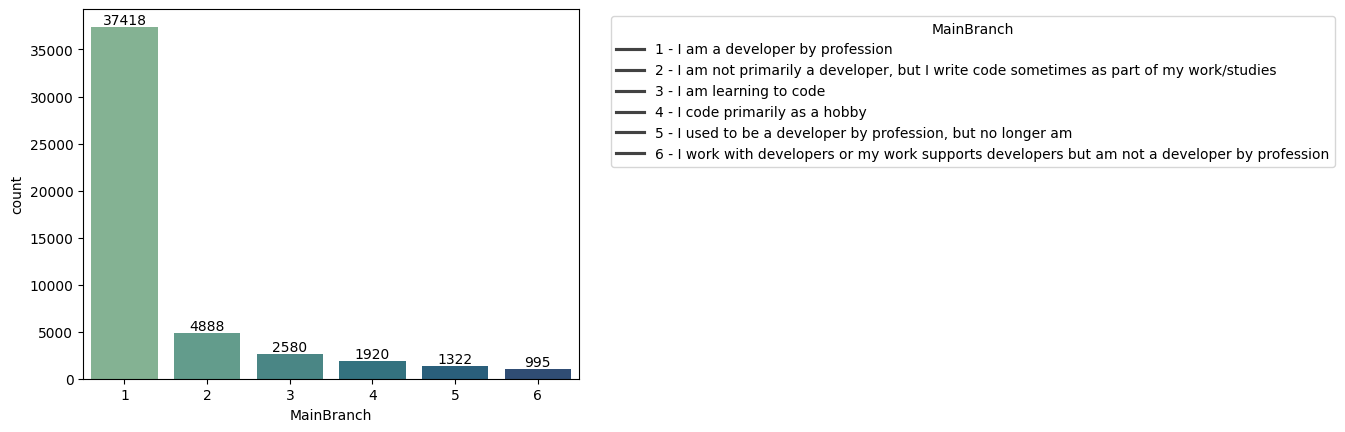

In [280]:
barplot_column(df_main_branch, "MainBranch", custom_palette="crest")

##### 3.2.2 - Employment analysis

In [281]:
df_employ = analysis_column(df_res_pub_final, "Employment")

Analysis of column: Employment
Total unique values: 7
Number of missing values: 846
Most frequent value: Employed (Count: 33709)


In [282]:
df_employ

,Employment,count
0,Employed,33709
1,"Independent contractor, freelancer, or self-em...",6700
2,Student,4420
3,Not employed,2222
4,NaN,846
5,Retired,708
6,I prefer not to say,518


In [283]:
df_employ['Employment'].fillna("Missing Answer", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\4180754343.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_employ['Employment'].fillna("Missing Answer", inplace=True)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:12: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df, x=column, y="count", hue=column, palette=palette)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


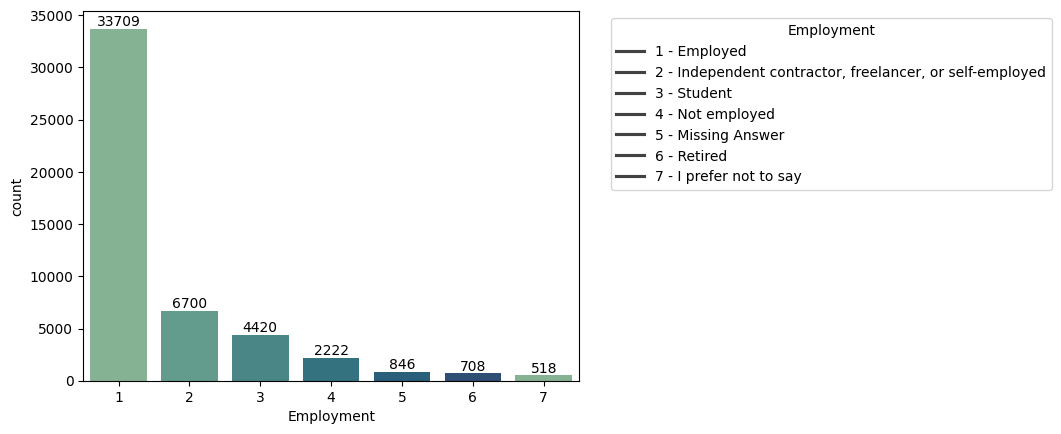

In [284]:
barplot_column(df_employ, "Employment", custom_palette="crest")

##### 3.2.3 - Age Analysis

In [285]:
df_age = analysis_column(df_res_pub_final, "Age")

Analysis of column: Age
Total unique values: 7
Number of missing values: 0
Most frequent value: 25-34 years old (Count: 16485)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:12: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df, x=column, y="count", hue=column, palette=palette)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


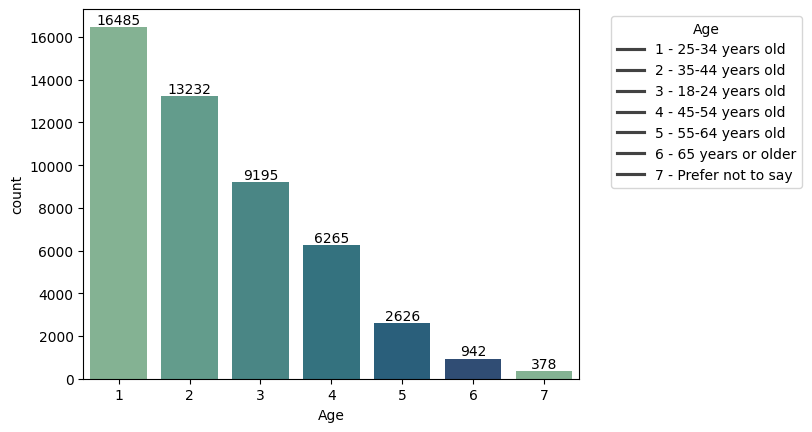

In [286]:
barplot_column(df_age, "Age", custom_palette="crest")

##### 3.2.4 - EdLevel

In [287]:
df_edlevel = analysis_column(df_res_pub_final, "EdLevel")

Analysis of column: EdLevel
Total unique values: 9
Number of missing values: 1036
Most frequent value: Bachelor’s degree (B.A., B.S., B.Eng., etc.) (Count: 20247)


In [288]:
df_edlevel['EdLevel'].fillna("Missing Answer", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\1057398177.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_edlevel['EdLevel'].fillna("Missing Answer", inplace=True)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:12: UserWarning: 
The palette list has fewer values (6) than needed (9) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df, x=column, y="count", hue=column, palette=palette)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


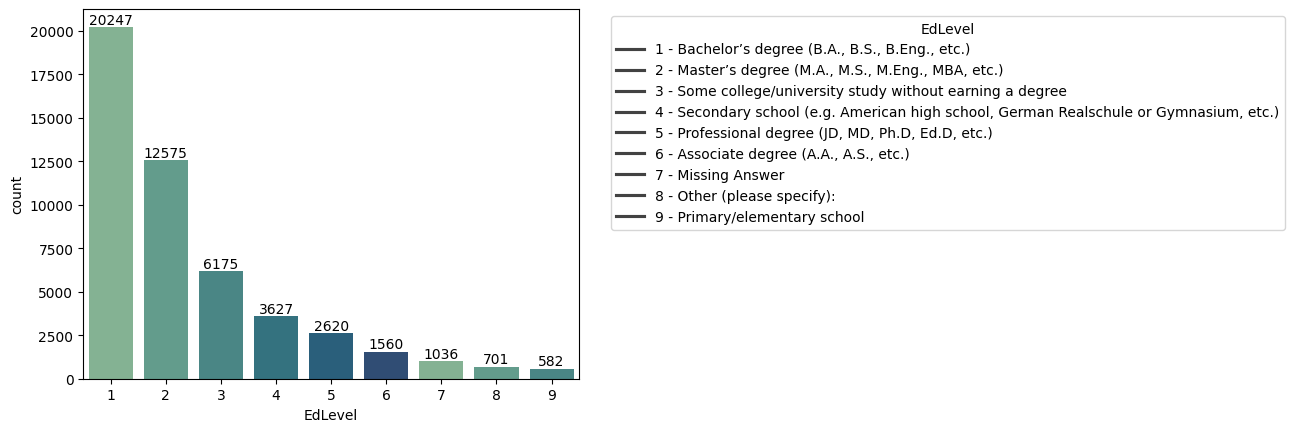

In [289]:
barplot_column(df_edlevel, "EdLevel", custom_palette="crest")

##### 3.2.5 - WorkExp

In [290]:
df_work_exp = analysis_column(df_res_pub_final, "WorkExp")

Analysis of column: WorkExp
Total unique values: 73
Number of missing values: 6279
Most frequent value: 10.0 (Count: 2883)


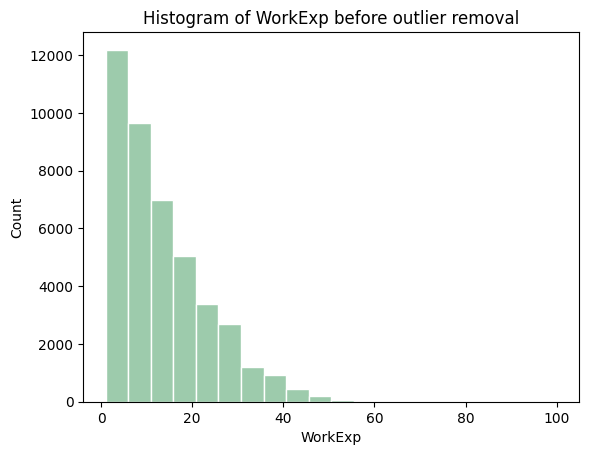

In [291]:
column = "WorkExp"
plt.title(f'Histogram of {column} before outlier removal')
temp_palette = sns.color_palette("crest")
ax = sns.histplot(data=df_res_pub_final, x=column, bins=20, color=temp_palette[0], edgecolor='white')

##### 3.2.6 - LearnCodeChoose

In [292]:
df_learn_code_choose = analysis_column(df_res_pub_final, "LearnCodeChoose") 

Analysis of column: LearnCodeChoose
Total unique values: 4
Number of missing values: 2322
Most frequent value: Yes, I am not new to coding but am learning new coding techniques or programming language (Count: 32316)


In [293]:
df_learn_code_choose['LearnCodeChoose'].fillna("Missing Answer", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\89513354.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_learn_code_choose['LearnCodeChoose'].fillna("Missing Answer", inplace=True)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:12: UserWarning: The palette list has more values (6) than needed (4), which may not be intended.
  ax = sns.barplot(data=df, x=column, y="count", hue=column, palette=palette)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


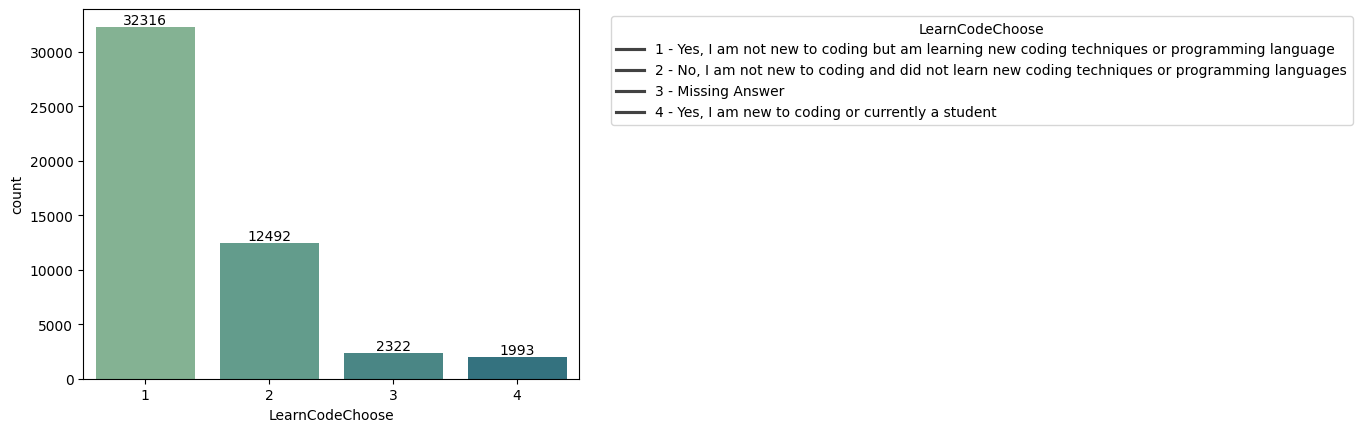

In [294]:
barplot_column(df_learn_code_choose, "LearnCodeChoose", custom_palette="crest")

##### 3.2.7 - LearnCodeAI

In [295]:
df_learn_code_ai = analysis_column(df_res_pub_final, "LearnCodeAI")

Analysis of column: LearnCodeAI
Total unique values: 6
Number of missing values: 3970
Most frequent value: Yes, I learned how to use AI-enabled tools required for my job or to benefit my career (Count: 16385)


In [296]:
df_learn_code_ai['LearnCodeAI'].fillna("Missing Answer", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\2860481457.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_learn_code_ai['LearnCodeAI'].fillna("Missing Answer", inplace=True)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


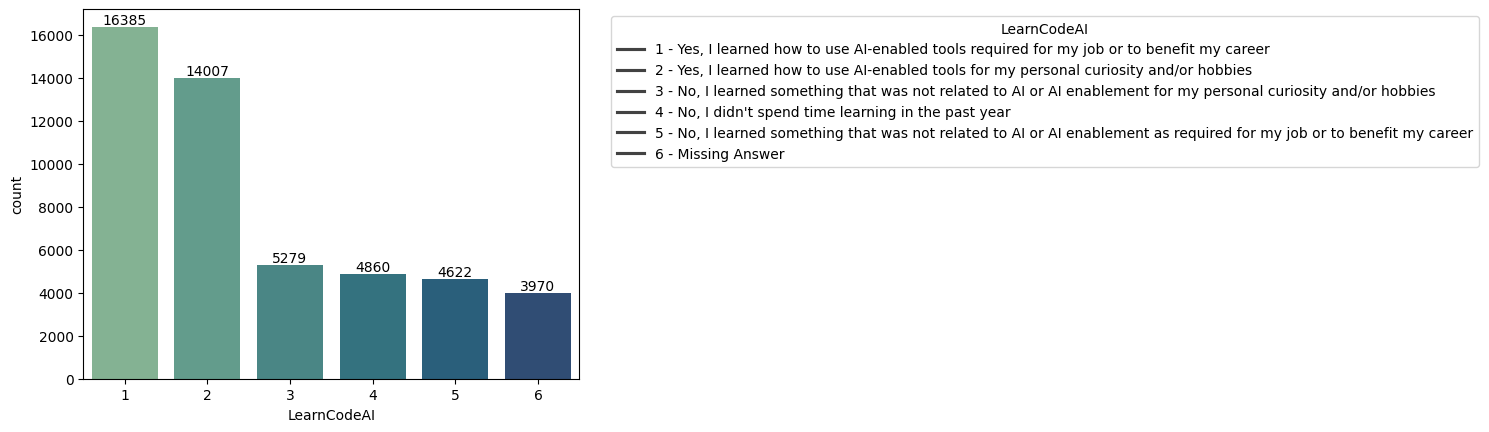

In [297]:
barplot_column(df_learn_code_ai, "LearnCodeAI", custom_palette="crest")

##### 3.2.8 - YearsCode

In [298]:
df_years_code = analysis_column(df_res_pub_final, "YearsCode")

Analysis of column: YearsCode
Total unique values: 79
Number of missing values: 6123
Most frequent value: 10.0 (Count: 3104)


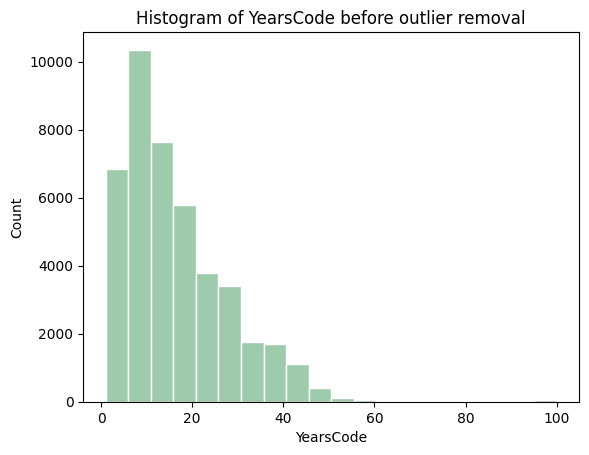

In [299]:
column = "YearsCode"
plt.title(f'Histogram of {column} before outlier removal')
temp_palette = sns.color_palette("crest")
ax = sns.histplot(data=df_res_pub_final, x=column, bins=20, color=temp_palette[0], edgecolor='white')

##### 3.2.9 - DevType

In [300]:
df_dev_type = analysis_column(df_res_pub_final, "DevType")

Analysis of column: DevType
Total unique values: 33
Number of missing values: 5487
Most frequent value: Developer, full-stack (Count: 12339)


In [301]:
df_dev_type['DevType'].fillna("Missing Answer", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\3768729960.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_dev_type['DevType'].fillna("Missing Answer", inplace=True)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:12: UserWarning: 
The palette list has fewer values (6) than needed (33) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df, x=column, y="count", hue=column, palette=palette)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


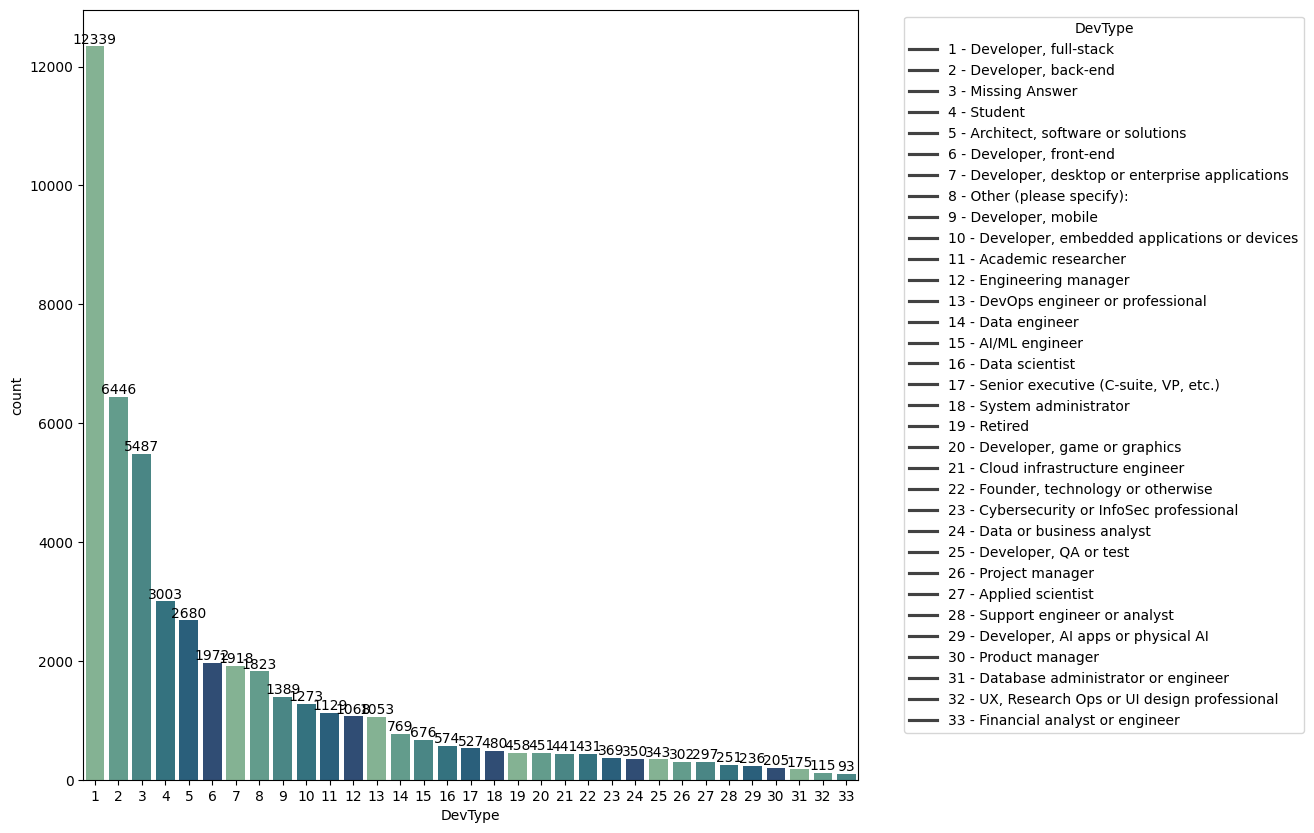

In [302]:
plt.figure(figsize=(10, 10))
barplot_column(df_dev_type, "DevType", custom_palette="crest")

##### 3.2.10 - OrgSize

In [303]:
df_org_size = analysis_column(df_res_pub_final, "OrgSize")

Analysis of column: OrgSize
Total unique values: 10
Number of missing values: 14979
Most frequent value: 20 to 99 employees (Count: 6680)


In [304]:
df_org_size['OrgSize'].fillna("Missing Answer", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\3233352795.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_org_size['OrgSize'].fillna("Missing Answer", inplace=True)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:12: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df, x=column, y="count", hue=column, palette=palette)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


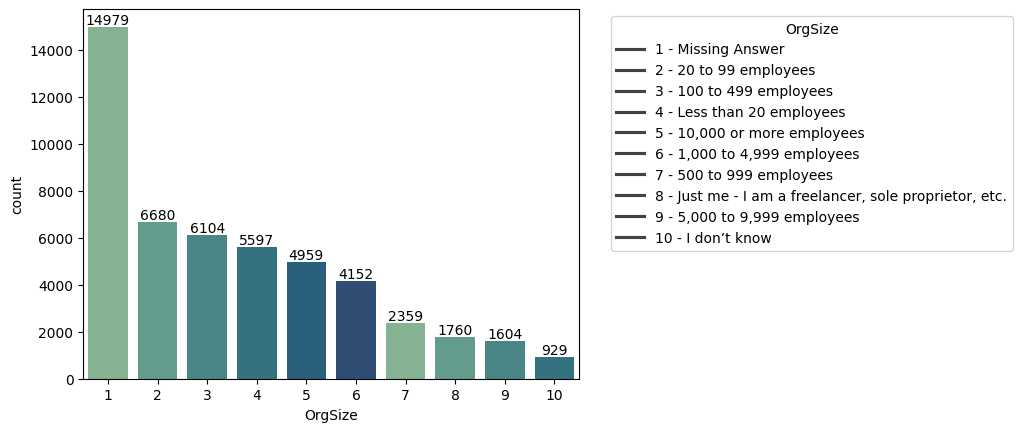

In [305]:
barplot_column(df_org_size, "OrgSize", custom_palette="crest")

##### 3.2.11 - RemoteWork

In [306]:
df_remote = analysis_column(df_res_pub_final, "RemoteWork")

Analysis of column: RemoteWork
Total unique values: 6
Number of missing values: 15376
Most frequent value: Remote (Count: 10924)


In [307]:
df_remote['RemoteWork'].fillna("Missing Answer", inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\2783694561.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_remote['RemoteWork'].fillna("Missing Answer", inplace=True)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


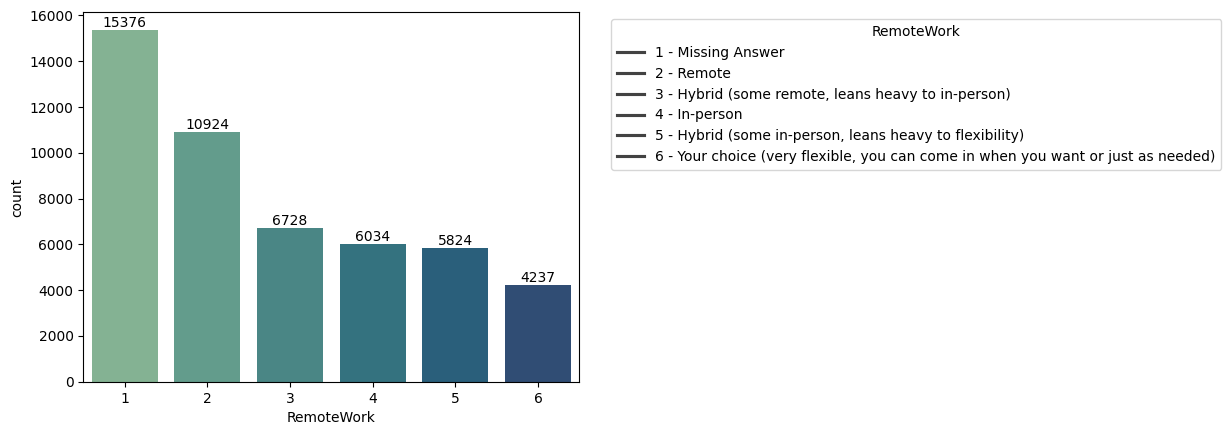

In [308]:
barplot_column(df_remote, "RemoteWork", custom_palette="crest")

##### 3.2.12 - Industry

C:\Users\User\AppData\Local\Temp\ipykernel_17616\2981116553.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_industry['Industry'].fillna("Missing Answer", inplace=True)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:12: UserWarning: 
The palette list has fewer values (6) than needed (16) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df, x=column, y="count", hue=column, palette=palette)


Analysis of column: Industry
Total unique values: 16
Number of missing values: 15516
Most frequent value: Software Development (Count: 16267)


c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


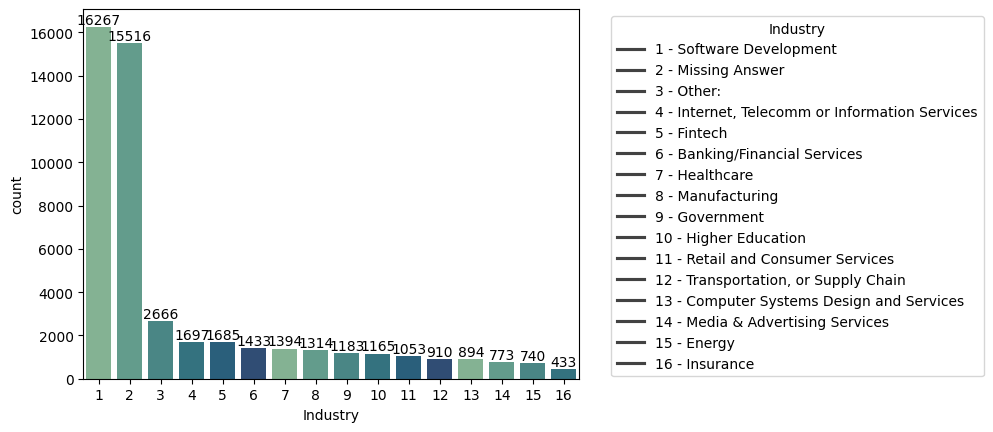

In [309]:
df_industry = analysis_column(df_res_pub_final, "Industry")
df_industry['Industry'].fillna("Missing Answer", inplace=True)
barplot_column(df_industry, "Industry", custom_palette="crest")

##### 3.2.13 - NewRole

Analysis of column: NewRole
Total unique values: 6
Number of missing values: 13632
Most frequent value: I have neither consider or transitioned into a new career or industry (Count: 16192)


C:\Users\User\AppData\Local\Temp\ipykernel_17616\27361018.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new_role['NewRole'].fillna("Missing Answer", inplace=True)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Category")


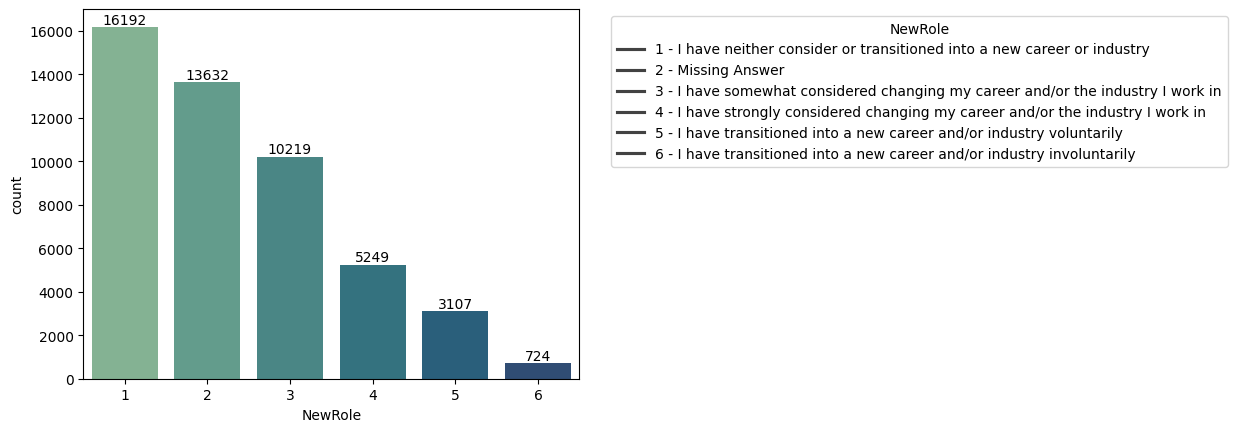

In [310]:
df_new_role = analysis_column(df_res_pub_final, "NewRole")
df_new_role['NewRole'].fillna("Missing Answer", inplace=True)
barplot_column(df_new_role, "NewRole", custom_palette="crest")


##### 3.2.14 - ToolCountWork

In [311]:
df_tool_count_work = analysis_column(df_res_pub_final, "ToolCountWork")

Analysis of column: ToolCountWork
Total unique values: 115
Number of missing values: 21541
Most frequent value: 5.0 (Count: 4755)


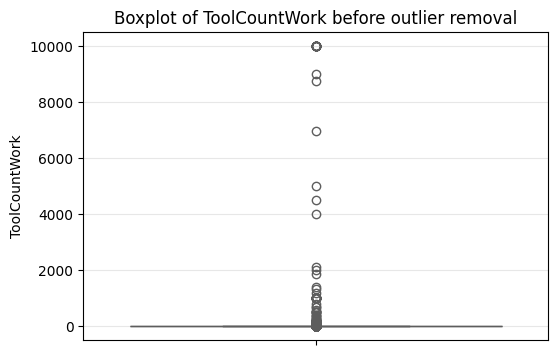

In [312]:
# Simple Boxplot
column = 'ToolCountWork'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub_final[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column} before outlier removal')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

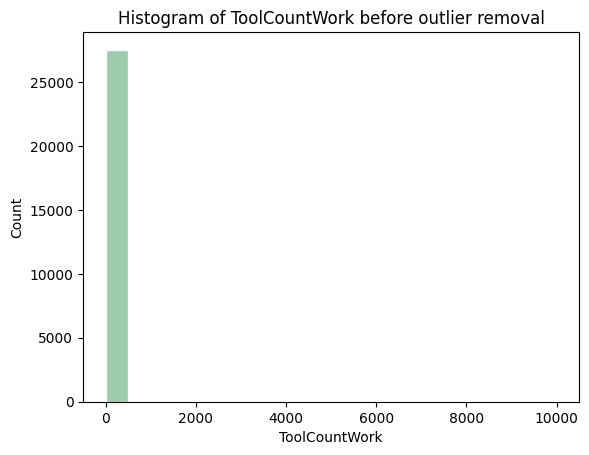

In [313]:
plt.title(f'Histogram of {column} before outlier removal')
temp_palette = sns.color_palette("crest")
ax = sns.histplot(data=df_res_pub_final, x=column, bins=20, color=temp_palette[0], edgecolor='white')

There are a lot of outliers, we will treat them later

##### 3.2.15 - Country

Analysis of column: Country
Total unique values: 178
Number of missing values: 13721
Most frequent value: United States of America (Count: 7226)
Only showing countries with more than 50 respondents


C:\Users\User\AppData\Local\Temp\ipykernel_17616\979337264.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_country['Country'].fillna("Missing Answer", inplace=True)
c:\Users\User\Documents\GitProjects\learning-projects\stackoverflow-udacity-project-course-2\commons\utils.py:12: UserWarning: 
The palette list has fewer values (6) than needed (66) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(data=df, x=column, y="count", hue=column, palette=palette)
c:\Users\User\Documents\GitProjects\lear

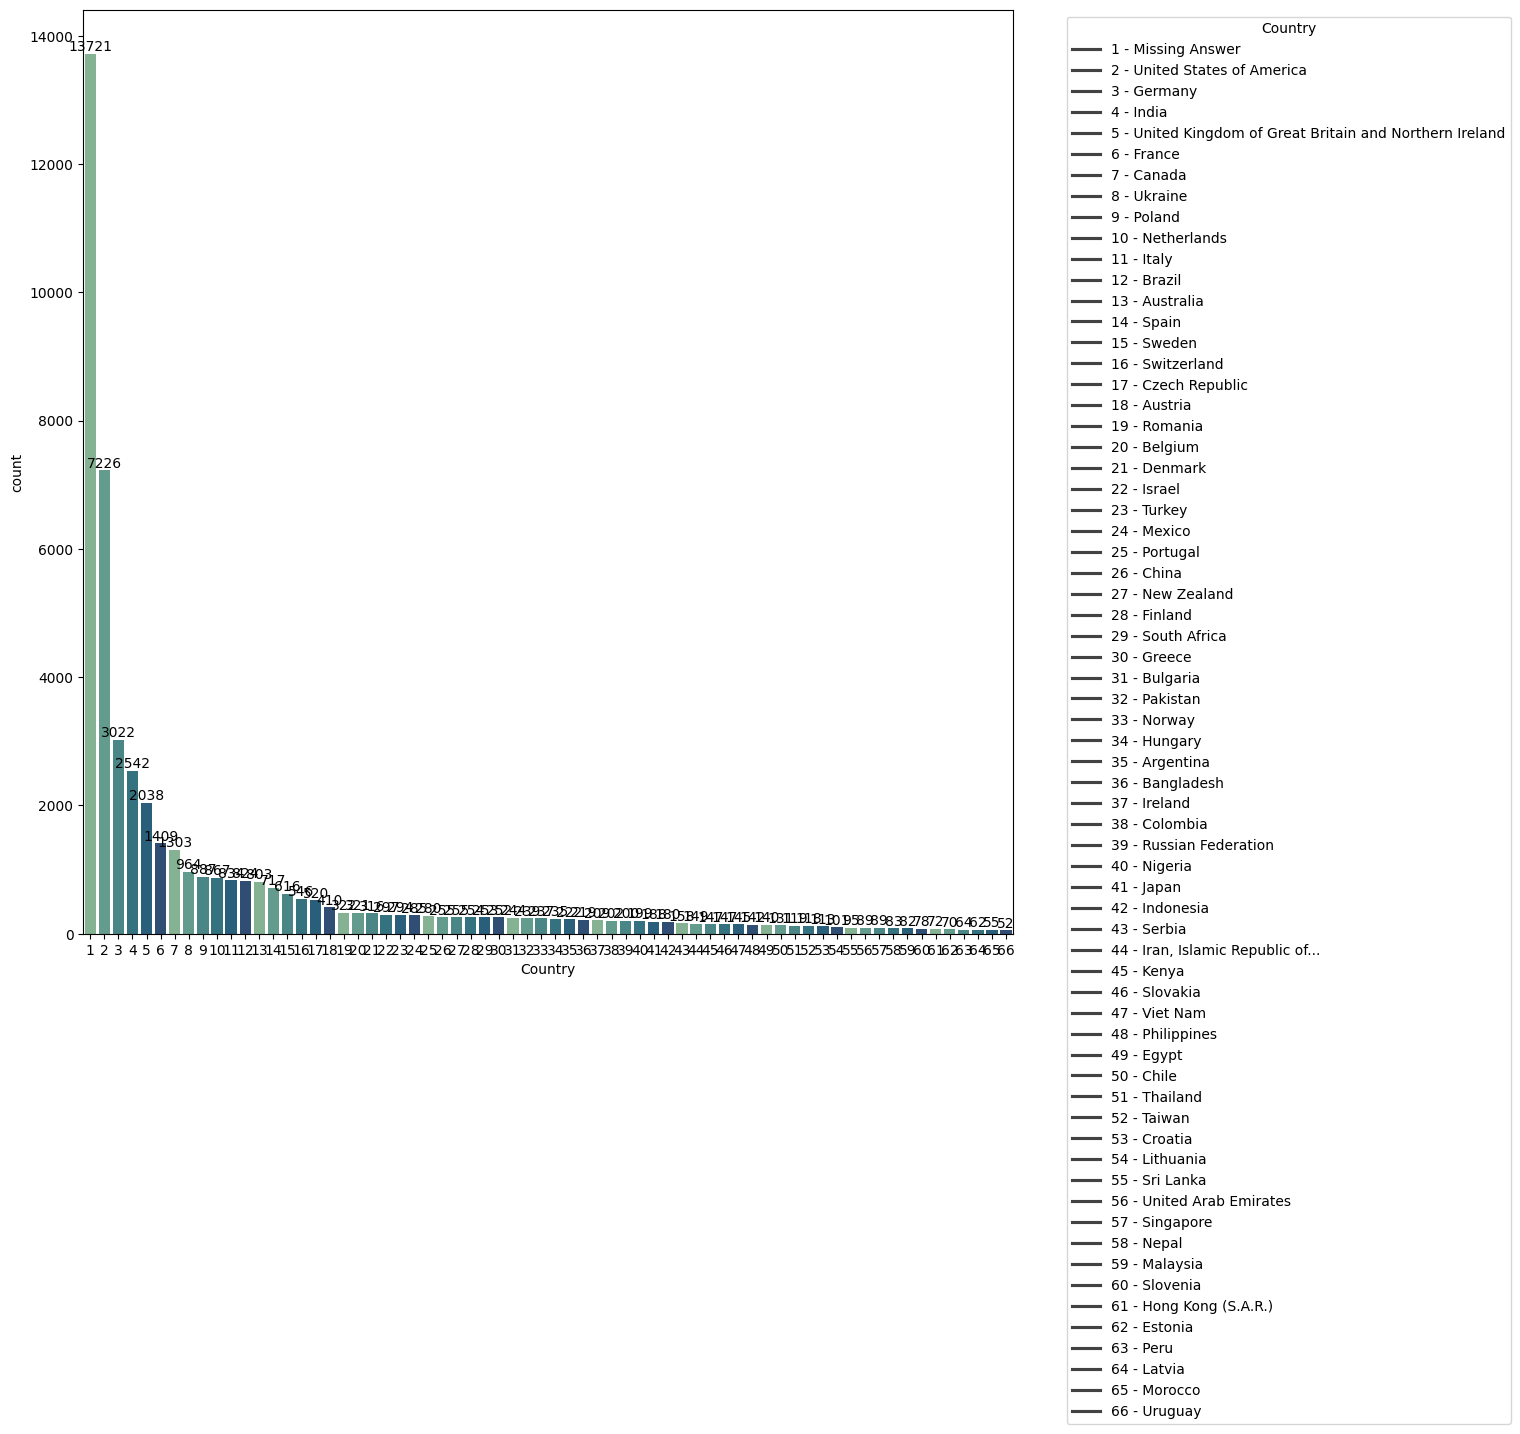

In [314]:
plt.figure(figsize=(12, 12))
df_country = analysis_column(df_res_pub_final, "Country")
df_country['Country'].fillna("Missing Answer", inplace=True)

print("Only showing countries with more than 50 respondents")
df_country = df_country[df_country["count"]>50]
barplot_column(df_country, "Country", custom_palette="crest")

##### 3.2.16 - Other columns
The other columns are mostly yes/no questions or filling options that are going to be OneHotEncoded.

## 4 - Data Preparation

### 4.0 - Selecting population of interest

In the column "MainBranch", we filter out the respondents in categories "I am learning to code", "I code primarily as a hobby" and "I used to be a developer by profession, but no longer am" because we are trying to predict salary. As the people belonging to these categories don't have their jobs direct connected with the survey, we treat them as outliers. 

In [315]:
# Validate the filter
print(f"Before: \n{df_res_pub_final.MainBranch.value_counts()}")

# Filter out categories not directly related to professional developers
df_res_pub_final = df_res_pub_final[~df_res_pub_final["MainBranch"].isin([
    "I am learning to code",
    "I code primarily as a hobby",
    "I used to be a developer by profession, but no longer am"
])]

# Validate the filter
print(f"\nAfter: \n{df_res_pub_final.MainBranch.value_counts()}")

Before: 
MainBranch
I am a developer by profession                                                                37418
I am not primarily a developer, but I write code sometimes as part of my work/studies          4888
I am learning to code                                                                          2580
I code primarily as a hobby                                                                    1920
I used to be a developer by profession, but no longer am                                       1322
I work with developers or my work supports developers but am not a developer by profession      995
Name: count, dtype: int64

After: 
MainBranch
I am a developer by profession                                                                37418
I am not primarily a developer, but I write code sometimes as part of my work/studies          4888
I work with developers or my work supports developers but am not a developer by profession      995
Name: count, dtype: int64


For the "Employment" column, we filter out the respondents in categories "Student", "Not employed", "Retired" and "I prefer not to say" for the same reaseon as in "MainBranch"

In [316]:

print(f"Before: \n{df_res_pub_final.Employment.value_counts()}")

# Filter out categories without direct professional connection
df_res_pub_final = df_res_pub_final[~df_res_pub_final["Employment"].isin([
    "Student",
    "Not employed",
    "Retired",
    "I prefer not to say"
])]

# Validate the filter
print(f"\nAfter: \n{df_res_pub_final.Employment.value_counts()}")

Before: 
Employment
Employed                                                32249
Independent contractor, freelancer, or self-employed     6117
Student                                                  2346
Not employed                                             1413
I prefer not to say                                       294
Retired                                                   223
Name: count, dtype: int64

After: 
Employment
Employed                                                32249
Independent contractor, freelancer, or self-employed     6117
Name: count, dtype: int64


Finally, for the "LanguageChoice" columns, we filter only the respondents that answered "yes". These are the people that worked with programming languages in the past year.

In [317]:
print(f"Before: \n{df_res_pub_final.LanguageChoice.value_counts()}")

# Filter out categories without direct professional connection
df_res_pub_final = df_res_pub_final[(df_res_pub_final["LanguageChoice"] == "Yes")]

# Validate the filter
print(f"\nAfter: \n{df_res_pub_final.LanguageChoice.value_counts()}")

Before: 
LanguageChoice
Yes    25870
No       395
Name: count, dtype: int64

After: 
LanguageChoice
Yes    25870
Name: count, dtype: int64


### 4.1 - Treating Values
Treating outliers and missing values

#### Dropping unnecessary columns

In [318]:
df_res_pub_final = df_res_pub_final.drop(['MainBranch', 'Employment', 'LanguageChoice'], axis=1)

In [319]:
df_res_pub_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25870 entries, 0 to 49121
Data columns (total 48 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Age                                       25870 non-null  object 
 1   EdLevel                                   25839 non-null  object 
 2   WorkExp                                   25506 non-null  float64
 3   LearnCodeChoose                           25856 non-null  object 
 4   LearnCodeAI                               25829 non-null  object 
 5   YearsCode                                 25693 non-null  float64
 6   DevType                                   25870 non-null  object 
 7   OrgSize                                   23361 non-null  object 
 8   RemoteWork                                23215 non-null  object 
 9   Industry                                  25817 non-null  object 
 10  NewRole                                

In [320]:
df_res_pub_final.shape

(25870, 48)

##### 4.1.0 - Age

In [321]:
df_res_pub_final.Age.value_counts()

Age
25-34 years old      9159
35-44 years old      8207
45-54 years old      3996
18-24 years old      2468
55-64 years old      1640
65 years or older     329
Prefer not to say      71
Name: count, dtype: int64

In [322]:
col_age_cat = 'Age'
prefix_age_cat = 'age_cat_'
df_res_pub_final = apply_ohe(df_res_pub_final, col_age_cat, prefix_age_cat)

##### 4.1.1 - Education Level
We will transform the labels into numerical values. These numbers will represent an ordered scale based on the commonly perceived academic progression (“natural order”). We will fill missing values with 0.

In [323]:
education_order_index = {
    "Other (please specify):": 0,
    "Primary/elementary school": 1,
    "Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)": 2,
    "Some college/university study without earning a degree": 3,
    "Associate degree (A.A., A.S., etc.)": 4,
    "Bachelor’s degree (B.A., B.S., B.Eng., etc.)": 5,
    "Master’s degree (M.A., M.S., M.Eng., MBA, etc.)": 6,
    "Professional degree (JD, MD, Ph.D, Ed.D, etc.)": 7
}

In [324]:
df_res_pub_final.EdLevel = df_res_pub_final.EdLevel.map(education_order_index)

In [325]:
df_res_pub_final.EdLevel = df_res_pub_final.EdLevel.fillna(0)

In [326]:
assert df_res_pub_final['EdLevel'].isnull().sum() == 0

In [327]:
df_res_pub_final = normalize_column(df_res_pub_final, column='EdLevel', type='MinMaxScaler')


Normalized Series (Scikit-Learn MinMaxScaler):
[0.85714286 0.57142857 0.71428571 ... 0.42857143 0.71428571 0.57142857]


In [328]:
assert df_res_pub_final['EdLevel'].isnull().sum() == 0

##### 4.1.2 - Country analysis

Analysing missing data

In [329]:
df_res_pub_final.Country.isnull().sum()

np.int64(0)

Analysing country distribuition

In [330]:
df_country = df_res_pub_final.Country.value_counts().reset_index()

In [331]:
dict_country = {
    'United States of America':'United States',
    'United Kingdom of Great Britain and Northern Ireland':'United Kingdom',
    'Czech Republic':'Czechia',
    'Russian Federation':'Russia',
    'Iran, Islamic Republic of...':'Iran',
    'Viet Nam':'Vietnam',
    'Hong Kong (S.A.R.)':'Hong Kong',
    'Republic of Korea':'South Korea',
    'Republic of North Macedonia':'North Macedonia',
    'Isle of Man':'United Kingdom',
    'Syrian Arab Republic':'Syria',
    'Republic of Moldova':'Moldova',
    'United Republic of Tanzania':'Tanzania',
    "Côte d'Ivoire":'Ivory Coast',
    'Democratic Republic of the Congo':'DR Congo',
    'Swaziland':'Eswatini',
    'Congo, Republic of the...':'DR Congo',
    'Libyan Arab Jamahiriya':'Libya',
    "Democratic People's Republic of Korea":'South Korea',
    "Lao People's Democratic Republic":"Laos"}

In [332]:
df_res_pub_final["treatedCountry"] = df_res_pub_final.Country.map(dict_country).fillna(df_res_pub_final.Country)

In [333]:
df_res_pub_final.treatedCountry

0              Ukraine
1          Netherlands
2              Ukraine
3              Ukraine
4              Ukraine
             ...      
49088    United States
49098           Poland
49105            Egypt
49106     South Africa
49121           France
Name: treatedCountry, Length: 25870, dtype: object

In [334]:
df_res_pub_final = pd.merge(df_res_pub_final, df_country_gdp, left_on='treatedCountry', right_on='country', how='left')

In [335]:
df_res_pub_final

,Age,EdLevel,WorkExp,LearnCodeChoose,LearnCodeAI,YearsCode,DevType,OrgSize,RemoteWork,Industry,...,age_cat_25-34 years old,age_cat_35-44 years old,age_cat_45-54 years old,age_cat_55-64 years old,age_cat_65 years or older,age_cat_Prefer not to say,treatedCountry,most_gdp_pc,country,gdp_per_capita
0,25-34 years old,0.857143,8.0,"Yes, I am not new to coding but am learning ne...","Yes, I learned how to use AI-enabled tools for...",14.0,"Developer, mobile",20 to 99 employees,Remote,Fintech,...,1,0,0,0,0,0,Ukraine,83.0,Ukraine,5758.99
1,25-34 years old,0.571429,2.0,"Yes, I am not new to coding but am learning ne...","Yes, I learned how to use AI-enabled tools for...",10.0,"Developer, back-end",500 to 999 employees,"Hybrid (some in-person, leans heavy to flexibi...",Retail and Consumer Services,...,1,0,0,0,0,0,Netherlands,194.0,Netherlands,70605.53
2,35-44 years old,0.714286,10.0,"Yes, I am not new to coding but am learning ne...","Yes, I learned how to use AI-enabled tools for...",12.0,"Developer, front-end",NaN,NaN,Software Development,...,0,1,0,0,0,0,Ukraine,83.0,Ukraine,5758.99
3,35-44 years old,0.714286,4.0,"Yes, I am not new to coding but am learning ne...","Yes, I learned how to use AI-enabled tools for...",5.0,"Developer, back-end","10,000 or more employees",Remote,Retail and Consumer Services,...,0,1,0,0,0,0,Ukraine,83.0,Ukraine,5758.99
4,35-44 years old,0.857143,21.0,"No, I am not new to coding and did not learn n...","Yes, I learned how to use AI-enabled tools for...",22.0,Engineering manager,NaN,NaN,Software Development,...,0,1,0,0,0,0,Ukraine,83.0,Ukraine,5758.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25865,35-44 years old,0.714286,15.0,"No, I am not new to coding and did not learn n...","Yes, I learned how to use AI-enabled tools req...",10.0,Engineering manager,100 to 499 employees,Remote,Software Development,...,0,1,0,0,0,0,United States,198.0,United States,89677.89
25866,45-54 years old,1.000000,8.0,"No, I am not new to coding and did not learn n...","Yes, I learned how to use AI-enabled tools req...",6.0,DevOps engineer or professional,"1,000 to 4,999 employees",In-person,Software Development,...,0,0,1,0,0,0,Poland,145.0,Poland,25040.60
25867,18-24 years old,0.428571,1.0,"Yes, I am not new to coding but am learning ne...","Yes, I learned how to use AI-enabled tools req...",1.0,"Developer, back-end",20 to 99 employees,In-person,Software Development,...,0,0,0,0,0,0,Egypt,57.0,Egypt,3160.11
25868,45-54 years old,0.714286,29.0,"Yes, I am not new to coding but am learning ne...","Yes, I learned how to use AI-enabled tools req...",29.0,"Developer, desktop or enterprise applications",100 to 499 employees,"Hybrid (some in-person, leans heavy to flexibi...",Software Development,...,0,0,1,0,0,0,South Africa,87.0,South Africa,6517.09


In [336]:
df_res_pub_final['most_gdp_pc'].isnull().sum()

np.int64(62)

In [337]:
# Dropping rows without data
df_res_pub_final = df_res_pub_final.dropna(subset = 'most_gdp_pc')

In [338]:
df_res_pub_final.drop(['most_gdp_pc','country'], axis=1, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\70886421.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_res_pub_final.drop(['most_gdp_pc','country'], axis=1, inplace=True)


##### 4.1.3 - gdp_per_capita

In [339]:
df_res_pub_final.gdp_per_capita

0         5758.99
1        70605.53
2         5758.99
3         5758.99
4         5758.99
           ...   
25865    89677.89
25866    25040.60
25867     3160.11
25868     6517.09
25869    49526.71
Name: gdp_per_capita, Length: 25808, dtype: float64

In [340]:
df_res_pub_final.gdp_per_capita.isnull().sum()

np.int64(0)

In [341]:
df_res_pub_final = normalize_column(df_res_pub_final, column='gdp_per_capita', type='MinMaxScaler')


Normalized Series (Scikit-Learn MinMaxScaler):
[0.03975568 0.49991144 0.03975568 ... 0.02131384 0.04513521 0.3503346 ]


C:\Users\User\AppData\Local\Temp\ipykernel_17616\2114100015.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = s_normalized.flatten()


In [342]:
df_res_pub_final = df_res_pub_final[~(df_res_pub_final.gdp_per_capita==0)].reset_index(drop=True)

##### 4.1.4 - Work Experience

**Treating missing data**

In [343]:
df_work_xp = df_res_pub_final.WorkExp.value_counts().reset_index()

In [344]:
# Number of people without work experience data
df_res_pub_final['WorkExp'].isnull().sum()

np.int64(363)

In [345]:
# Number of people with work experience data
df_res_pub_final['WorkExp'].notnull().sum()

np.int64(25444)

In [346]:
index = df_res_pub_final['WorkExp'].notnull()

In [347]:
# Mean income for those with work experience data
df_res_pub_final.loc[index, 'ConvertedCompYearly'].mean()


np.float64(101873.5308388775)

In [348]:
df_work_xp_salary = df_res_pub_final.groupby('WorkExp').agg({'ConvertedCompYearly':'mean'})

<Axes: xlabel='WorkExp'>

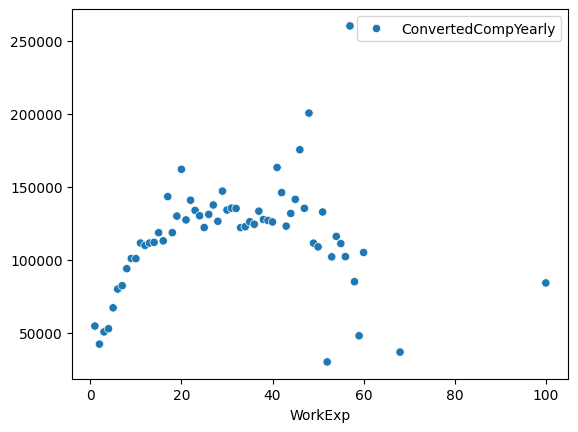

In [349]:
sns.scatterplot(df_work_xp_salary)

Doing a simple scatterplot, we notice some outliers that will be treated. <br>
But first we will treat the missing values.

In [350]:
df_res_pub_final.loc[df_res_pub_final['WorkExp'] == 2, 'ConvertedCompYearly'].mean()

np.float64(42293.38888888889)

In [351]:
df_miss_work_exp = df_res_pub_final[~index]

In [352]:
# Mean income for those with work experience data
df_res_pub_final.loc[~index, 'ConvertedCompYearly'].mean()


np.float64(38411.206896551725)

In [353]:
df_miss_work_exp.Age.value_counts()

Age
18-24 years old      199
25-34 years old       98
35-44 years old       43
45-54 years old       11
Prefer not to say      5
55-64 years old        4
65 years or older      3
Name: count, dtype: int64

With most of the missing data belonging to the Age categories of 18-24 followed by the ages of 25-34, we can assume that those are probably the people starting their careers. Furthermore, their incomes are compatible as well, so we will fill the missing data with 2 years of WorkExp as it is the least income we have in our dataset.

In [354]:
df_res_pub_final['WorkExp'] = df_res_pub_final['WorkExp'].fillna(2)

**Treating Outliers**

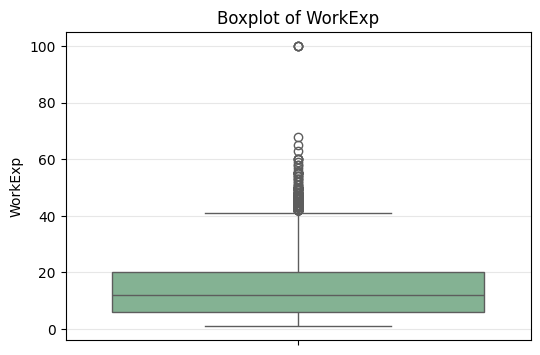

In [355]:
# Simple Boxplot
column = 'WorkExp'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub_final[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column}')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

As most people retire at most at the age of 75, we can consider those with more than 60 years of Working Experience as outliers. The curve from the scatterplot support this decision.

In [356]:
df_res_pub_final = df_res_pub_final[df_res_pub_final['WorkExp'] <= 60]

In [357]:
df_res_pub_final.shape

(25800, 57)

There is one specific age that has the 'ConvertedCompYearly' far above the average

In [358]:
df_work_xp_salary[df_work_xp_salary['ConvertedCompYearly'] == df_work_xp_salary['ConvertedCompYearly'].max()]

,ConvertedCompYearly
WorkExp,
57.0,260000.0


Usually, these high salaries for the average of an age group, are due to a small number of very high salaries skewing the mean upwards. <br>
Let's verify the number of respondents with 57 years of work experience.

In [359]:
df_work_xp_quant = df_res_pub_final.groupby('WorkExp').agg({'ConvertedCompYearly':'count'})

As expected, there is only one person with 57 years of work expercience, which is an outlier and we will remove it from the analysis.

In [360]:
df_res_pub_final = df_res_pub_final[df_res_pub_final['WorkExp'] != 57]

Doing the same analysis for the second biggest earning by age group

In [361]:
df_work_xp_salary = df_res_pub_final.groupby('WorkExp').agg({'ConvertedCompYearly':'mean'})
df_work_xp_salary[df_work_xp_salary['ConvertedCompYearly'] == df_work_xp_salary['ConvertedCompYearly'].max()]

,ConvertedCompYearly
WorkExp,
48.0,200362.666667


In [362]:
age_with_max_salary = df_work_xp_salary[df_work_xp_salary['ConvertedCompYearly'] == df_work_xp_salary['ConvertedCompYearly'].max()].index[0]
df_work_xp_quant = df_res_pub_final.groupby('WorkExp').agg({'ConvertedCompYearly':'count'})
df_work_xp_quant.loc[age_with_max_salary]

ConvertedCompYearly    6
Name: 48.0, dtype: int64

Now there are more people, so we will be leaving as it is.

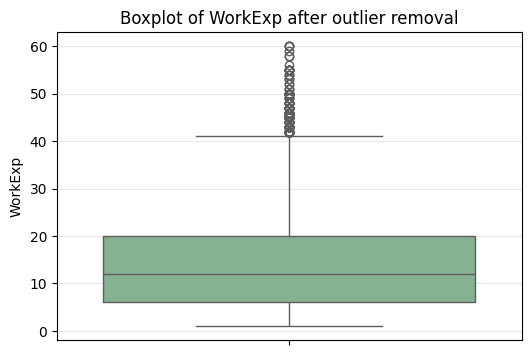

In [363]:
# Simple Boxplot
column = 'WorkExp'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub_final[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column} after outlier removal')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

<Axes: xlabel='WorkExp'>

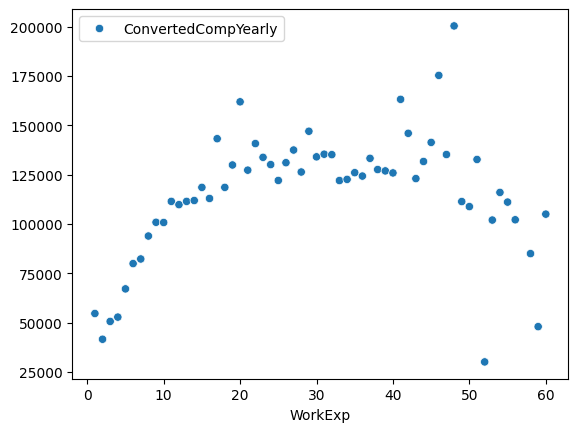

In [364]:
sns.scatterplot(df_work_xp_salary)

In [365]:
sum(df_res_pub_final.WorkExp == 0)

0

<Axes: xlabel='WorkExp', ylabel='Count'>

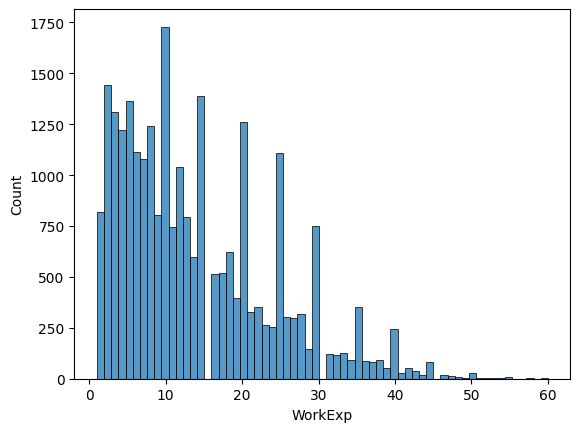

In [366]:
sns.histplot(df_res_pub_final.WorkExp)


In [367]:
# Aplying log transformation in order to treat the skewed curve.
# (log1p(x) = log(1 + x))
df_res_pub_final['WorkExp_log'] = np.log1p(df_res_pub_final['WorkExp'])

<Axes: xlabel='WorkExp_log', ylabel='Count'>

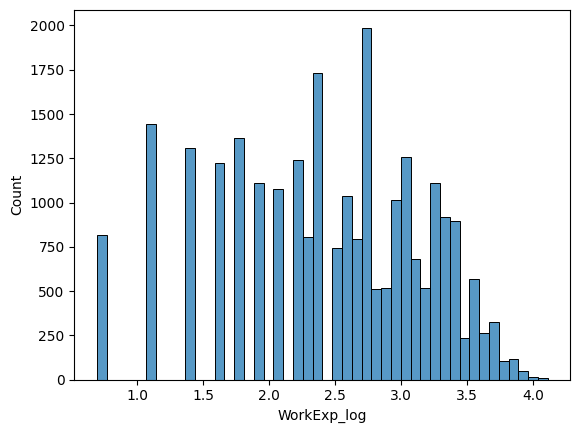

In [368]:
sns.histplot(df_res_pub_final.WorkExp_log)


In [369]:
df_work_xp_salary_log = df_res_pub_final.groupby('WorkExp_log').agg({'ConvertedCompYearly':'mean'})

<Axes: xlabel='WorkExp_log'>

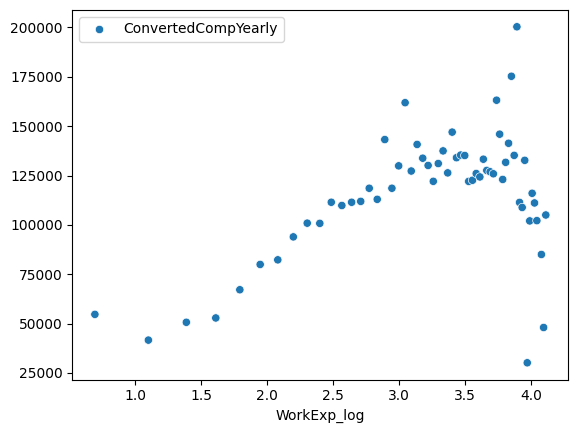

In [370]:
sns.scatterplot(df_work_xp_salary_log)

In [371]:
df_res_pub_final = normalize_column(df_res_pub_final, column='WorkExp', type='MinMaxScaler')
df_res_pub_final = normalize_column(df_res_pub_final, column='WorkExp_log', type='MinMaxScaler')


Normalized Series (Scikit-Learn MinMaxScaler):
[0.11864407 0.01694915 0.15254237 ... 0.         0.47457627 0.15254237]

Normalized Series (Scikit-Learn MinMaxScaler):
[0.44008124 0.11863591 0.49879591 ... 0.         0.79235423 0.49879591]


<Axes: xlabel='WorkExp', ylabel='Count'>

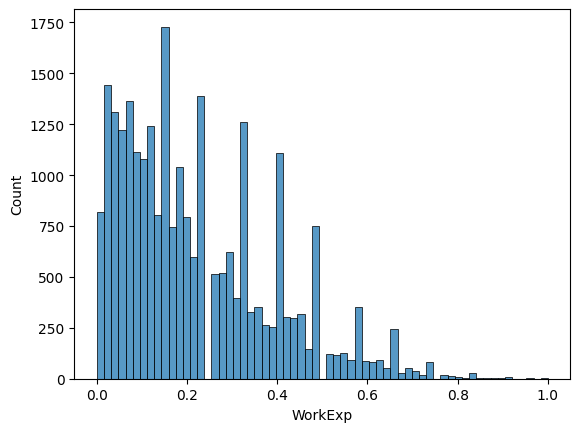

In [372]:
sns.histplot(df_res_pub_final.WorkExp)


##### 4.1.5 - LearnCodeChoose

Filling the nulls with the "No" answer

In [373]:
df_res_pub_final['LearnCodeChoose'].value_counts()

LearnCodeChoose
Yes, I am not new to coding but am learning new coding techniques or programming language      18236
No, I am not new to coding and did not learn new coding techniques or programming languages     7288
Yes, I am new to coding or currently a student                                                   261
Name: count, dtype: int64

In [374]:
df_res_pub_final["LearnCodeChoose"] = df_res_pub_final["LearnCodeChoose"].fillna("No, I am not new to coding and did not learn new coding techniques or programming languages")

In [375]:
df_res_pub_final['LearnCodeChoose'].value_counts()

LearnCodeChoose
Yes, I am not new to coding but am learning new coding techniques or programming language      18236
No, I am not new to coding and did not learn new coding techniques or programming languages     7302
Yes, I am new to coding or currently a student                                                   261
Name: count, dtype: int64

Splitting into "Yes":1 and "No":0

In [376]:
learnCodeChooseDict = {"Yes, I am not new to coding but am learning new coding techniques or programming language": 1, 
 "Yes, I am new to coding or currently a student": 1, 
 "No, I am not new to coding and did not learn new coding techniques or programming languages": 0}

In [377]:
df_res_pub_final['LearnCodeChoose'] = df_res_pub_final['LearnCodeChoose'].map(learnCodeChooseDict)

##### 4.1.6 - LearnCodeAI
Similar process as LearnCodeChoose feature

In [378]:
df_res_pub_final["LearnCodeAI"].value_counts()

LearnCodeAI
Yes, I learned how to use AI-enabled tools required for my job or to benefit my career                                10150
Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies                                    7637
No, I learned something that was not related to AI or AI enablement as required for my job or to benefit my career     2934
No, I learned something that was not related to AI or AI enablement for my personal curiosity and/or hobbies           2627
No, I didn't spend time learning in the past year                                                                      2411
Name: count, dtype: int64

In [379]:
df_res_pub_final["LearnCodeAI"].isnull().sum()

np.int64(40)

In [380]:
learnCodeAIDict = {"Yes, I learned how to use AI-enabled tools required for my job or to benefit my career": 1,
                   "Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies": 1,
                   "No, I learned something that was not related to AI or AI enablement as required for my job or to benefit my career": 0,
                   "No, I learned something that was not related to AI or AI enablement for my personal curiosity and/or hobbies": 0,
                   "No, I didn't spend time learning in the past year": 0}

In [381]:
df_res_pub_final["LearnCodeAI"] = df_res_pub_final["LearnCodeAI"].map(learnCodeAIDict)

In [382]:
df_res_pub_final["LearnCodeAI"].fillna(0, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\1803404256.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_res_pub_final["LearnCodeAI"].fillna(0, inplace=True)


##### 4.1.7 - YearsCode

Removing outliers in 'YearsCode'

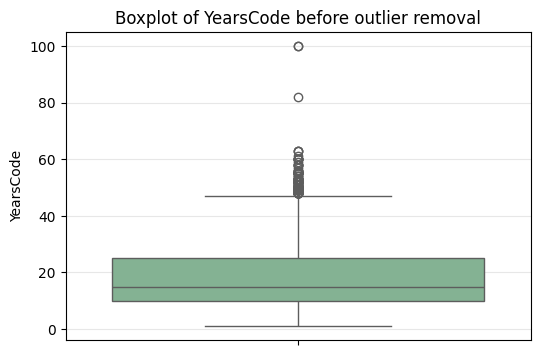

In [383]:
# Simple Boxplot
column = 'YearsCode'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub_final[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column} before outlier removal')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [384]:
df_res_pub_final = df_res_pub_final[df_res_pub_final["YearsCode"] <= 65].reset_index(drop=True)

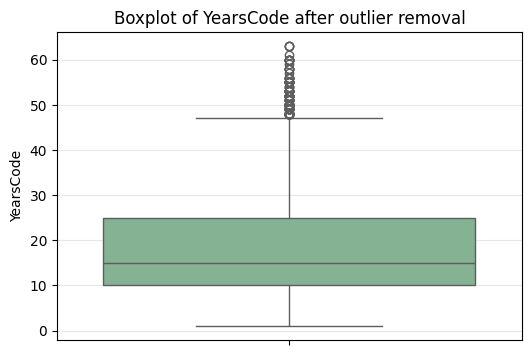

In [385]:
# Simple Boxplot
column = 'YearsCode'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub_final[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column} after outlier removal')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

Treating missing data

In [386]:
df_res_pub_final.YearsCode.isnull().sum()

np.int64(0)

<Axes: xlabel='YearsCode', ylabel='Count'>

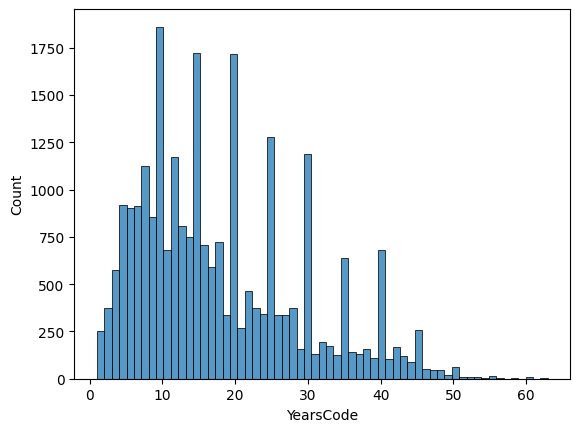

In [387]:
sns.histplot(df_res_pub_final.YearsCode)

In [388]:
# Aplying log transformation in order to treat the skewed curve.
# (log1p(x) = log(1 + x))
df_res_pub_final['YearsCode_log'] = np.log1p(df_res_pub_final['YearsCode'])

In [389]:
df_res_pub_final = normalize_column(df_res_pub_final, column='YearsCode', type='MinMaxScaler')
df_res_pub_final = normalize_column(df_res_pub_final, column='YearsCode_log', type='MinMaxScaler')


Normalized Series (Scikit-Learn MinMaxScaler):
[0.20967742 0.14516129 0.17741935 ... 0.         0.4516129  0.20967742]

Normalized Series (Scikit-Learn MinMaxScaler):
[0.58137812 0.49188632 0.54008794 ... 0.         0.78137812 0.58137812]


##### 4.1.8 - DevType

In [390]:
df_res_pub_final.DevType.isnull().sum()

np.int64(0)

We dropped the "Student" and "Retired" labels when treating the "Employed" column. However, in the DevType column there are still some data with "Student" and "Retired" labels so we will drop them. 

In [391]:
df_res_pub_final.DevType.value_counts()

DevType
Developer, full-stack                            8342
Developer, back-end                              4294
Architect, software or solutions                 1853
Developer, desktop or enterprise applications    1336
Developer, front-end                             1213
Developer, embedded applications or devices       887
Developer, mobile                                 823
DevOps engineer or professional                   749
Other (please specify):                           711
Engineering manager                               676
Academic researcher                               555
Data engineer                                     516
AI/ML engineer                                    383
Data scientist                                    372
Senior executive (C-suite, VP, etc.)              319
Cloud infrastructure engineer                     274
Founder, technology or otherwise                  264
System administrator                              252
Developer, game or g

In [392]:
df_res_pub_final = df_res_pub_final[~df_res_pub_final['DevType'].isin(['Student', 'Retired'])]

In [393]:
df_res_pub_final.shape

(25543, 59)

In [394]:
# Apply OneHotEncoding to column
df_temp = pd.get_dummies(df_res_pub_final['DevType'], prefix='dev_type_').astype(int)

df_res_pub_final = pd.concat([df_res_pub_final, df_temp], axis=1)

##### 4.1.9 - OrgSize

Treating missing values. Here we will fill the missing data with the "I don't know" label.

In [395]:
df_res_pub_final.OrgSize.value_counts()

OrgSize
20 to 99 employees                                    4634
100 to 499 employees                                  4337
Less than 20 employees                                3693
10,000 or more employees                              3448
1,000 to 4,999 employees                              2919
500 to 999 employees                                  1673
5,000 to 9,999 employees                              1135
Just me - I am a freelancer, sole proprietor, etc.     837
I don’t know                                           413
Name: count, dtype: int64

In [396]:
company_size_order = {
    "I don’t know": 0,
    "Just me - I am a freelancer, sole proprietor, etc.": 1,
    "Less than 20 employees": 2,
    "20 to 99 employees": 3,
    "100 to 499 employees": 4,
    "500 to 999 employees": 5,
    "1,000 to 4,999 employees": 6,
    "5,000 to 9,999 employees": 7,
    "10,000 or more employees": 8
}

In [397]:
df_res_pub_final.OrgSize = df_res_pub_final.OrgSize.map(company_size_order)

In [398]:
df_res_pub_final.OrgSize.isnull().sum()

np.int64(2454)

In [399]:
df_res_pub_final.OrgSize = df_res_pub_final.OrgSize.fillna(0)

In [400]:
df_res_pub_final = normalize_column(df_res_pub_final, column='OrgSize', type='MinMaxScaler')


Normalized Series (Scikit-Learn MinMaxScaler):
[0.375 0.625 0.    ... 0.375 0.5   0.375]


##### 4.1.10 - RemoteWork

Treating missing values

In [401]:
df_res_pub_final.RemoteWork.isnull().sum()

np.int64(2592)

In [402]:
df_res_pub_final.RemoteWork.value_counts()

RemoteWork
Remote                                                                          7592
Hybrid (some remote, leans heavy to in-person)                                  4618
Hybrid (some in-person, leans heavy to flexibility)                             4163
In-person                                                                       3595
Your choice (very flexible, you can come in when you want or just as needed)    2983
Name: count, dtype: int64

As there are almost as many nulls as some classes, we will create a label "No answer" for the missing values

In [403]:
df_res_pub_final.RemoteWork = df_res_pub_final.RemoteWork.fillna("No answer")

In [404]:
work_flexibility_order = {
    "No answer": 0,
    "In-person": 1,
    "Hybrid (some remote, leans heavy to in-person)": 2,
    "Hybrid (some in-person, leans heavy to flexibility)": 3,
    "Remote": 4,
    "Your choice (very flexible, you can come in when you want or just as needed)": 5
}

In [405]:
df_res_pub_final.RemoteWork = df_res_pub_final.RemoteWork.map(work_flexibility_order)

In [406]:
df_res_pub_final = normalize_column(df_res_pub_final, column='RemoteWork', type='MinMaxScaler')


Normalized Series (Scikit-Learn MinMaxScaler):
[0.8 0.6 0.  ... 0.2 0.6 0.4]


##### 4.1.11 - Industry

Treating missing values

In [407]:
df_res_pub_final.Industry.value_counts()

Industry
Software Development                          12377
Other:                                         1973
Fintech                                        1327
Internet, Telecomm or Information Services     1272
Banking/Financial Services                     1103
Healthcare                                     1094
Manufacturing                                   980
Government                                      905
Retail and Consumer Services                    804
Higher Education                                796
Transportation, or Supply Chain                 700
Computer Systems Design and Services            637
Media & Advertising Services                    599
Energy                                          572
Insurance                                       358
Name: count, dtype: int64

Let's fill the missing values with the label "Other:"

In [408]:
df_res_pub_final.Industry = df_res_pub_final.Industry.fillna("Other:")

In [409]:
# Apply OneHotEncoding to column
df_temp = pd.get_dummies(df_res_pub_final['Industry'], prefix = 'industry_').astype(int)

df_res_pub_final = pd.concat([df_res_pub_final, df_temp], axis=1)

##### 4.1.12 - NewRole

Treating missing values

In [410]:
df_res_pub_final.NewRole.value_counts()

NewRole
I have neither consider or transitioned into a new career or industry          11788
I have somewhat considered changing my career and/or the industry I work in     7616
I have strongly considered changing my career and/or the industry I work in     3345
I have transitioned into a new career and/or industry voluntarily               2242
I have transitioned into a new career and/or industry involuntarily              462
Name: count, dtype: int64

For this variable, we will divide the labels in two groups:
- Those that transitioned - voluntarily or not
- Those that did not - we will include the missing values in this category

In [411]:
dict_new_role = {
    "I have neither consider or transitioned into a new career or industry": 0,
    "I have somewhat considered changing my career and/or the industry I work in": 0,
    "I have strongly considered changing my career and/or the industry I work in": 0,
    "I have transitioned into a new career and/or industry voluntarily": 1,
    "I have transitioned into a new career and/or industry involuntarily": 1
}

In [412]:
df_res_pub_final.NewRole = df_res_pub_final.NewRole.map(dict_new_role)

In [413]:
df_res_pub_final.NewRole = df_res_pub_final.NewRole.fillna(0)

In [414]:
df_res_pub_final.NewRole.value_counts()

NewRole
0.0    22839
1.0     2704
Name: count, dtype: int64

##### 4.1.13 - ToolCountWork
Removing Outliers

In [415]:
df_tool_count = df_res_pub_final.ToolCountWork.value_counts()

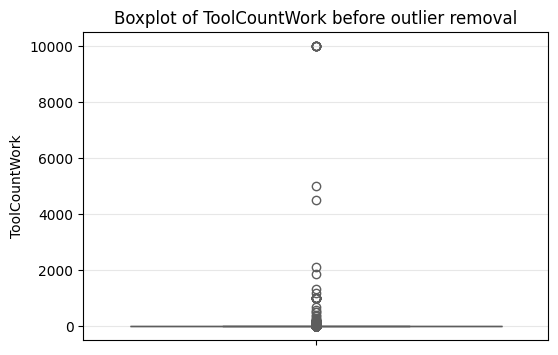

In [416]:
# Simple Boxplot
column = 'ToolCountWork'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub_final[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column} before outlier removal')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [417]:
df_tool_count = df_tool_count.reset_index()

Removing above 500

In [418]:
df_tool_count2 = df_tool_count[df_tool_count['ToolCountWork'] <= 500]

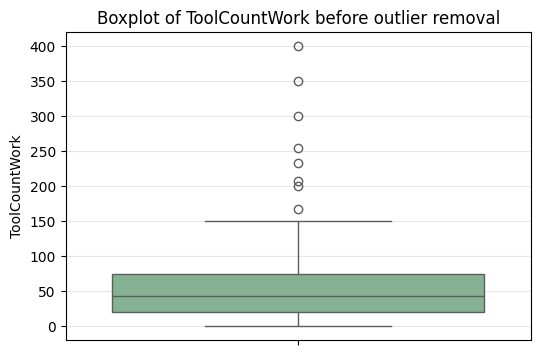

In [419]:
# Simple Boxplot
column = 'ToolCountWork'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_tool_count2[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column} before outlier removal')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

We can see that there are still some outliers, let's cut those above 260

In [420]:
df_tool_count2 = df_tool_count[df_tool_count['ToolCountWork'] <= 260]

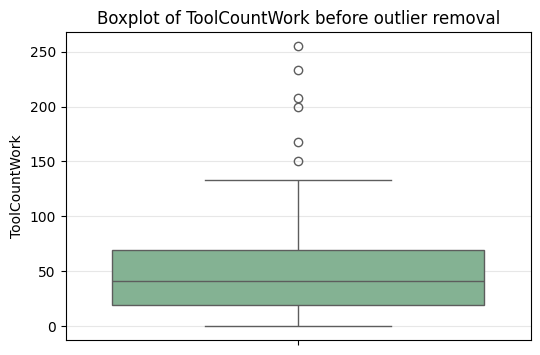

In [421]:
# Simple Boxplot
column = 'ToolCountWork'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_tool_count2[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column} before outlier removal')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

We removed a lot of outliers because we will use the mean to fill those with missing data and those with extreme values

In [422]:
avg_tool_count = df_tool_count2['ToolCountWork'].mean().round()

In [423]:
df_res_pub_final["ToolCountWork"] = df_res_pub_final["ToolCountWork"].fillna(avg_tool_count)

In [424]:
index_tool_count_extreme = df_res_pub_final["ToolCountWork"] > 100

In [425]:
df_res_pub_final.loc[index_tool_count_extreme, "ToolCountWork"] = avg_tool_count

In [426]:
df_res_pub_final.ToolCountWork.value_counts()

ToolCountWork
56.0    4311
5.0     3676
10.0    3459
3.0     1916
4.0     1771
        ... 
49.0       1
62.0       1
90.0       1
95.0       1
39.0       1
Name: count, Length: 69, dtype: int64

<Axes: xlabel='ToolCountWork', ylabel='Count'>

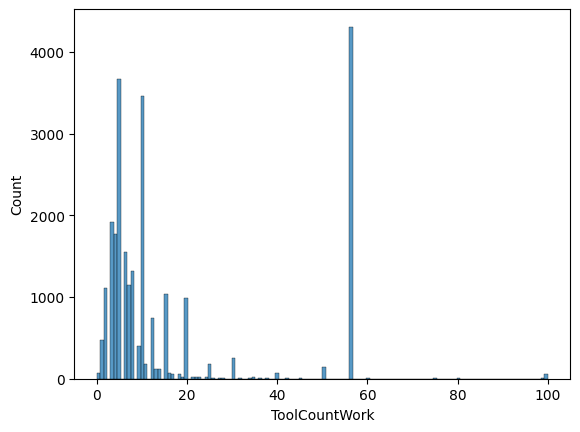

In [427]:
sns.histplot(df_res_pub_final.ToolCountWork)

The ToolCountWork variable exhibited extreme skewness and outliers, which is why the logarithmic transformation (log(x+1)) was applied. <br> Additionally, extreme value processing was performed to reduce the influence of outliers in the modeling process.

In [428]:
df_res_pub_final['ToolCountWork_w'] = df_res_pub_final['ToolCountWork'].clip(
    upper=df_res_pub_final['ToolCountWork'].quantile(0.99)
)


In [429]:
# Aplying log transformation in order to treat the skewed curve.
# (log1p(x) = log(1 + x))
df_res_pub_final['ToolCountWork_log'] = np.log1p(df_res_pub_final['ToolCountWork_w'])

<Axes: xlabel='ToolCountWork_log', ylabel='Count'>

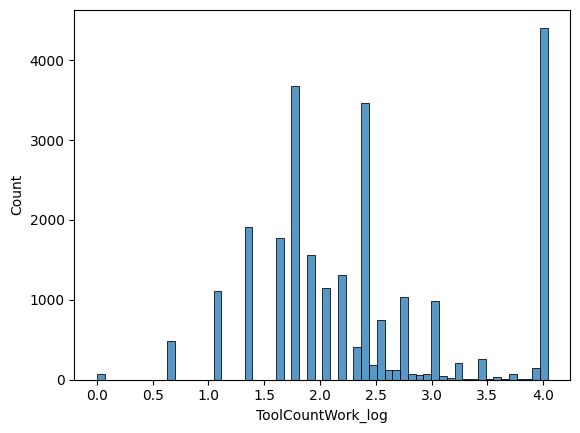

In [430]:
sns.histplot(df_res_pub_final.ToolCountWork_log)

In [431]:
df_res_pub_final = normalize_column(df_res_pub_final, column='ToolCountWork', type='MinMaxScaler')
df_res_pub_final = normalize_column(df_res_pub_final, column='ToolCountWork_log', type='MinMaxScaler')


Normalized Series (Scikit-Learn MinMaxScaler):
[0.07 0.06 0.03 ... 0.56 0.2  0.08]

Normalized Series (Scikit-Learn MinMaxScaler):
[0.5143248  0.48129742 0.3428832  ... 1.         0.75302593 0.54345702]


##### 4.1.14 - LanguageHaveWorkedWith


In [432]:
df_res_pub_final.LanguageHaveWorkedWith

0                         Bash/Shell (all shells);Dart;SQL
1                                                     Java
2                      Dart;HTML/CSS;JavaScript;TypeScript
3                                          Java;Kotlin;SQL
4        C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...
                               ...                        
25614                                           Python;SQL
25615    Ada;Assembly;Erlang;F#;Fortran;GDScript;Go;Groovy
25616    C++;Dart;GDScript;HTML/CSS;JavaScript;PHP;Powe...
25617    Bash/Shell (all shells);Delphi;PowerShell;Pyth...
25618                                               C#;SQL
Name: LanguageHaveWorkedWith, Length: 25543, dtype: object

Treating missing values and one hot encoding the languages

In [433]:
col_lang = 'LanguageHaveWorkedWith'
prefix_lang = 'lang_'

In [434]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_lang, prefix_lang)

##### 4.1.15 - DatabaseChoice
Filling missing values with "No"

In [435]:
df_res_pub_final.DatabaseChoice.value_counts()

DatabaseChoice
Yes    21437
No      3509
Name: count, dtype: int64

In [436]:
df_res_pub_final.DatabaseChoice = df_res_pub_final.DatabaseChoice.fillna("No")

##### 4.1.16 - DatabaseHaveWorkedWith
Treating missing values and one hot encoding the databases

In [437]:
df_res_pub_final.DatabaseHaveWorkedWith

0                               Cloud Firestore;PostgreSQL
1                                         Dynamodb;MongoDB
2                                 MongoDB;MySQL;PostgreSQL
3                                                      NaN
4        Elasticsearch;Microsoft SQL Server;MySQL;Oracl...
                               ...                        
25614                             Databricks SQL;Snowflake
25615                                                  NaN
25616                                         MySQL;SQLite
25617                                    PostgreSQL;SQLite
25618                           Microsoft SQL Server;MySQL
Name: DatabaseHaveWorkedWith, Length: 25543, dtype: object

In [438]:
col_db = 'DatabaseHaveWorkedWith'
prefix_db = 'db_'

In [439]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_db, prefix_db)

##### 4.1.17 - PlatformChoice
Filling missing values with "No"

In [440]:
df_res_pub_final.PlatformChoice.value_counts()

PlatformChoice
Yes    20099
No      4546
Name: count, dtype: int64

In [441]:
df_res_pub_final.PlatformChoice = df_res_pub_final.PlatformChoice.fillna("No")

##### 4.1.18 - PlatformHaveWorkedWith
Treating missing values and one hot encoding the platforms

In [442]:
col_plat = 'PlatformHaveWorkedWith'
prefix_plat = 'platform_'

In [443]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_plat, prefix_plat)

##### 4.1.19 - WebframeChoice
Filling missing values with "No"

In [444]:
df_res_pub_final.WebframeChoice.value_counts()

WebframeChoice
Yes    19585
No      5009
Name: count, dtype: int64

In [445]:
df_res_pub_final.WebframeChoice = df_res_pub_final.WebframeChoice.fillna("No")

##### 4.1.20 - WebframeHaveWorkedWith
Treating missing values and one hot encoding the web frameworks

In [446]:
col_wf = 'WebframeHaveWorkedWith'
prefix_wf = 'webframes_'

In [447]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_wf, prefix_wf)

##### 4.1.21 - DevEnvsChoice
Filling missing values with "No"

In [448]:
df_res_pub_final.DevEnvsChoice.value_counts()

DevEnvsChoice
Yes    20986
No      3516
Name: count, dtype: int64

In [449]:
df_res_pub_final.DevEnvsChoice = df_res_pub_final.DevEnvsChoice.fillna("No")

##### 4.1.22 - DevEnvsHaveWorkedWith
Treating missing values and one hot encoding the dev environments

In [450]:
col_devenvs = 'DevEnvsHaveWorkedWith'
prefix_devenvs = 'devenvs_'

In [451]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_devenvs, prefix_devenvs)

##### 4.1.23 - OpSysProfessional use
Treating missing values and one hot encoding the operational systems

In [452]:
col_os = 'OpSysProfessional use'
prefix_os = 'os_'

In [453]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_os, prefix_os)

##### 4.1.24 - OfficeStackAsyncHaveWorkedWith
Treating missing values and one hot encoding the office stacks

In [454]:
col_office_stack = 'OfficeStackAsyncHaveWorkedWith'
prefix_office_stack = 'office_stack_'

In [455]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_office_stack, prefix_office_stack)

##### 4.1.25 - CommPlatformHaveWorkedWith
Treating missing values and one hot encoding the community platforms

In [456]:
col_com = 'CommPlatformHaveWorkedWith'
prefix_com = 'community_'

In [457]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_com, prefix_com)

##### 4.1.26 - AIModelsChoice

Treating missing values - Filling with "No"

In [458]:
df_res_pub_final.AIModelsChoice.value_counts()

AIModelsChoice
Yes    13772
No     10140
Name: count, dtype: int64

In [459]:
df_res_pub_final.AIModelsChoice.isnull().sum()

np.int64(1631)

In [460]:
df_res_pub_final.AIModelsChoice = df_res_pub_final.AIModelsChoice.fillna("No")

##### 4.1.27 - AIModelsHaveWorkedWith
Treating missing values and one hot encoding the AI Models that the respondent have worked with

In [461]:
col_ai_worked_with = 'AIModelsHaveWorkedWith'
prefix_ai_worked_with = 'ai_worked_with_'

In [462]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_ai_worked_with, prefix_ai_worked_with)

##### 4.1.28 - AISelect

In [463]:
df_res_pub_final.AISelect.value_counts()

AISelect
Yes, I use AI tools daily                      12104
Yes, I use AI tools weekly                      4485
No, and I don't plan to                         3832
Yes, I use AI tools monthly or infrequently     3353
No, but I plan to soon                          1161
Name: count, dtype: int64

Let's treat those that user AI frequently (daily or weekly) as 1 and those that don't as 0 (including missing values)

In [464]:
ai_usage_map = {
    "Yes, I use AI tools daily": 1,
    "Yes, I use AI tools weekly": 1,
    "No, and I don't plan to": 0,
    "Yes, I use AI tools monthly or infrequently": 0,
    "No, but I plan to soon": 0
}

In [465]:
df_res_pub_final["AISelect"] = df_res_pub_final["AISelect"].map(ai_usage_map)

In [466]:
df_res_pub_final["AISelect"] = df_res_pub_final["AISelect"].fillna(0)

##### 4.1.29 - Use of AI
Columns:
- AIToolCurrently partially AI
- AIToolDon't plan to use AI for this task
- AIToolPlan to partially use AI
- AIToolPlan to mostly use AI
- AIToolCurrently mostly AI

Treating missing values and one hot encoding each column

**AIToolCurrently partially AI**

In [467]:
col_curr_part_ai = 'AIToolCurrently partially AI'
prefix_curr_part_ai = 'curr_part_ai_'

In [468]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_curr_part_ai, prefix_curr_part_ai)

**AIToolDon't plan to use AI for this task**

In [469]:
col_not_plan_use_ai = "AIToolDon't plan to use AI for this task"
prefix_not_plan_use_ai = 'not_plan_use_ai_'

In [470]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_not_plan_use_ai, prefix_not_plan_use_ai)

**AIToolPlan to partially use AI**

In [471]:
col_plan_part_use_ai = "AIToolPlan to partially use AI"
prefix_plan_part_use_ai = 'plan_part_use_ai_'

In [472]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_plan_part_use_ai, prefix_plan_part_use_ai)

**AIToolPlan to mostly use AI**

In [473]:
col_plan_most_use_ai = "AIToolPlan to mostly use AI"
prefix_plan_most_use_ai = 'plan_most_use_ai_'

In [474]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_plan_most_use_ai, prefix_plan_most_use_ai)

**AIToolCurrently mostly AI**

In [475]:
col_curr_most_use_ai = "AIToolCurrently mostly AI"
prefix_curr_most_use_ai = 'curr_most_use_ai_'

In [476]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_curr_most_use_ai, prefix_curr_most_use_ai)

##### 4.1.30 - AI Agents Impact

Columns:
- AIAgentImpactSomewhat agree
- AIAgentImpactNeutral
- AIAgentImpactSomewhat disagree
- AIAgentImpactStrongly agree
- AIAgentImpactStrongly disagree

Treating missing values and one hot encoding each column

**AIAgentImpactSomewhat agree**

In [477]:
col_impct_somewhat_agree = "AIAgentImpactSomewhat agree"
prefix_impct_somewhat_agree = 'impct_somewhat_agree_'

In [478]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_impct_somewhat_agree, prefix_impct_somewhat_agree)

**AIAgentImpactNeutral**

In [479]:
col_impct_neut = "AIAgentImpactNeutral"
prefix_impct_neut = 'impct_neut_'

In [480]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_impct_neut, prefix_impct_neut)

**AIAgentImpactSomewhat disagree**

In [481]:
col_impct_somewhat_disagree = "AIAgentImpactSomewhat disagree"
prefix_impct_somewhat_disagree = 'impct_somewhat_disagree_'

In [482]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_impct_somewhat_disagree, prefix_impct_somewhat_disagree)

**AIAgentImpactStrongly agree**

In [483]:
col_impct_strong_agree = "AIAgentImpactStrongly agree"
prefix_impct_strong_agree = 'impct_strong_agree_'

In [484]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_impct_strong_agree, prefix_impct_strong_agree)

**AIAgentImpactStrongly disagree**

In [485]:
col_impct_strong_disagree = "AIAgentImpactStrongly disagree"
prefix_impct_strong_disagree = 'impct_strong_disagree_'

In [486]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_impct_strong_disagree, prefix_impct_strong_disagree)

##### 4.1.31 - AI Challenges
Columns:

- AIAgentChallengesNeutral
- AIAgentChallengesSomewhat disagree
- AIAgentChallengesSomewhat agree
- AIAgentChallengesStrongly agree
- AIAgentChallengesStrongly disagree

Treating missing values and one hot encoding each column

**AIAgentChallengesNeutral**

In [487]:
col_chal_neut = "AIAgentChallengesNeutral"
prefix_chal_neut = 'chal_neut_'

In [488]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_chal_neut, prefix_chal_neut)

**AIAgentChallengesSomewhat disagree**

In [489]:
col_chal_somewhat_disagree = "AIAgentChallengesSomewhat disagree"
prefix_chal_somewhat_disagree = 'chal_somewhat_disagree_'

In [490]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_chal_somewhat_disagree, prefix_chal_somewhat_disagree)

**AIAgentChallengesStrongly agree**

In [491]:
col_chal_somewhat_agree = "AIAgentChallengesSomewhat agree"
prefix_chal_somewhat_agree = 'chal_somewhat_agree_'

In [492]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_chal_somewhat_agree, prefix_chal_somewhat_agree)

**AIAgentChallengesStrongly agree**

In [493]:
col_chal_strong_agree = "AIAgentChallengesStrongly agree"
prefix_chal_strong_agree = 'chal_strong_agree_'


In [494]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_chal_strong_agree, prefix_chal_strong_agree)

**AIAgentChallengesStrongly disagree**

In [495]:
col_chal_strong_disagree = "AIAgentChallengesStrongly disagree"
prefix_chal_strong_disagree = 'chal_strong_disagree_'


In [496]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_chal_strong_disagree, prefix_chal_strong_disagree)

##### 4.1.32 - AIAgentKnowledge
Treating missing values and one hot encoding AI Knowledge column

In [497]:
col_ai_agent_knowledge = "AIAgentKnowledge"
prefix_ai_agent_knowledge = 'ai_agent_knowledge_'


In [498]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_ai_agent_knowledge, prefix_ai_agent_knowledge)

##### 4.1.33 - AIAgentOrchestration
Treating missing values and one hot encoding AI Agent orchestration column

In [499]:
col_ai_agent_orchestration = "AIAgentOrchestration"
prefix_ai_agent_orchestration = 'ai_agent_orchestration_'


In [500]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_ai_agent_orchestration, prefix_ai_agent_orchestration)

##### 4.1.34 - AIAgentObserveSecure
Treating missing values and one hot encoding AI Agent observability and security column

In [501]:
col_ai_agent_observe = "AIAgentObserveSecure"
prefix_ai_agent_observe = 'ai_agent_observe_'

In [502]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_ai_agent_observe, prefix_ai_agent_observe)

##### 4.1.35 - AIAgentExternal
Treating missing values and one hot encoding external AI Agents column

In [503]:
col_ai_agent_external = "AIAgentExternal"
prefix_ai_agent_external = 'ai_agent_external_'

In [504]:
df_res_pub_final = apply_ohe(df_res_pub_final, col_ai_agent_external, prefix_ai_agent_external)

##### 4.1.3 - Target (ConvertedCompYearly) Analysis

**Treating missing values** <br>
Dropping the missing data as this is our target variable

In [505]:
df_res_pub_final.ConvertedCompYearly.isnull().sum()

np.int64(5480)

In [506]:
df_res_pub_final = df_res_pub_final.dropna(subset=['ConvertedCompYearly'])

In [507]:
df_res_pub_final.shape

(20063, 566)

<Axes: xlabel='ConvertedCompYearly', ylabel='Count'>

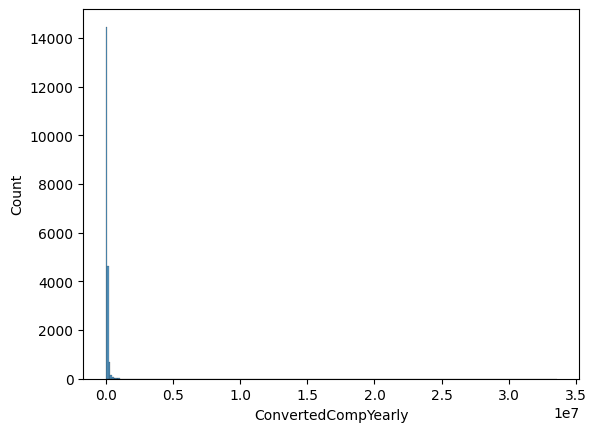

In [508]:
sns.histplot(df_res_pub_final.ConvertedCompYearly)

**Treating Outliers** <br>
Minimum Wage by Country Analysis

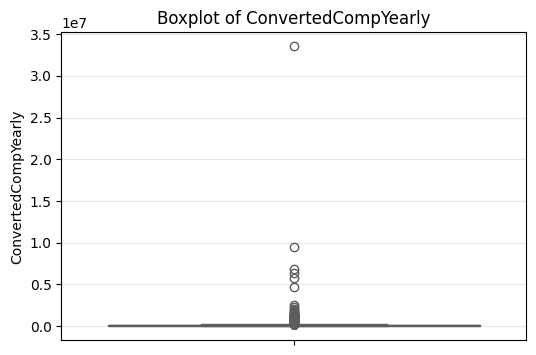

In [509]:
temp_palette = sns.color_palette("crest")

# Simple Boxplot
column = 'ConvertedCompYearly'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub_final[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column}')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

There are clear outliers in the dataset, let's remove them for starters

In [510]:
threshold_upper_salary = 400000
print((df_res_pub_final['ConvertedCompYearly'] > threshold_upper_salary).sum())
print(f"Percentage of data dropped: {(df_res_pub_final['ConvertedCompYearly'] > threshold_upper_salary).sum()/df_res_pub_final.shape[0]}")

216
Percentage of data dropped: 0.010766086826496536


In [511]:
df_res_pub_final = df_res_pub_final[df_res_pub_final['ConvertedCompYearly'] <= threshold_upper_salary]

<Axes: xlabel='ConvertedCompYearly', ylabel='Count'>

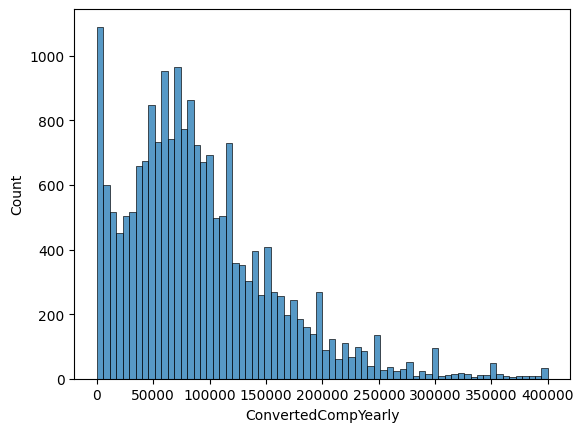

In [512]:
sns.histplot(df_res_pub_final.ConvertedCompYearly)

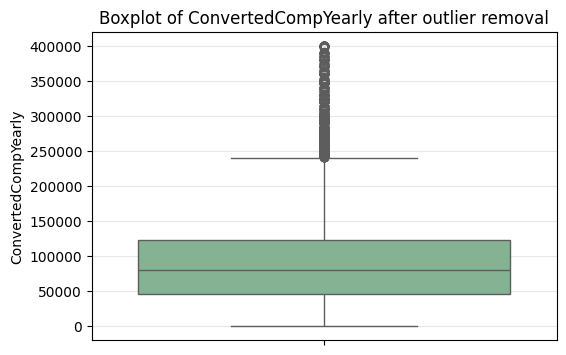

In [513]:
# Simple Boxplot
column = 'ConvertedCompYearly'
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_res_pub_final[column].dropna(), color=temp_palette[0])
plt.title(f'Boxplot of {column} after outlier removal')
plt.ylabel(column)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [514]:
df_country = pd.merge(df_country, df_minimum_wage, on="Country", how="left")

In [515]:
df_country

,Country,count,flagCode,MinimumWageHourly,MinimumWageAnnual
0,United States of America,5489,NaN,NaN,NaN
1,Germany,2274,DE,15.16,31537.0
2,United Kingdom of Great Britain and Northern I...,1582,NaN,NaN,NaN
3,India,1478,IN,0.27,674.0
4,France,1066,FR,14.05,25572.0
...,...,...,...,...,...
163,Democratic People's Republic of Korea,1,NaN,NaN,NaN
164,Lao People's Democratic Republic,1,NaN,NaN,NaN
165,Sierra Leone,1,SL,0.28,575.0
166,Cape Verde,1,CV,0.73,1673.0


In [516]:
df_country.sort_values(by='MinimumWageAnnual').head(10)

,Country,count,flagCode,MinimumWageHourly,MinimumWageAnnual
116,Cuba,6,CU,0.44,44.0
64,Georgia,36,GE,0.04,93.0
37,Bangladesh,125,BD,0.08,212.0
140,Tajikistan,2,TJ,0.13,265.0
160,Malawi,1,MW,0.11,266.0
103,Kyrgyzstan,8,KG,0.17,349.0
112,Madagascar,6,MG,0.18,376.0
110,Uganda,6,UG,0.20,426.0
165,Sierra Leone,1,SL,0.28,575.0
111,Zambia,6,ZM,0.24,596.0


Filtering Out Answers that are less than the minimum wage

In [517]:
df_res_pub_final = pd.merge(df_res_pub_final, df_minimum_wage[['Country', 'MinimumWageAnnual']], on='Country', how='left')

In [518]:
df_res_pub_final['MinimumWageAnnual'].fillna(0, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_17616\3969028718.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_res_pub_final['MinimumWageAnnual'].fillna(0, inplace=True)


In [519]:
df_res_pub_final.shape

(19847, 567)

In [520]:
# Number of inconsistent answers
(df_res_pub_final['ConvertedCompYearly'] < df_res_pub_final['MinimumWageAnnual']).sum()

np.int64(737)

In [521]:
df_res_pub_final = df_res_pub_final[df_res_pub_final['ConvertedCompYearly'] >= df_res_pub_final['MinimumWageAnnual']].reset_index(drop=True)

<Axes: xlabel='ConvertedCompYearly', ylabel='Count'>

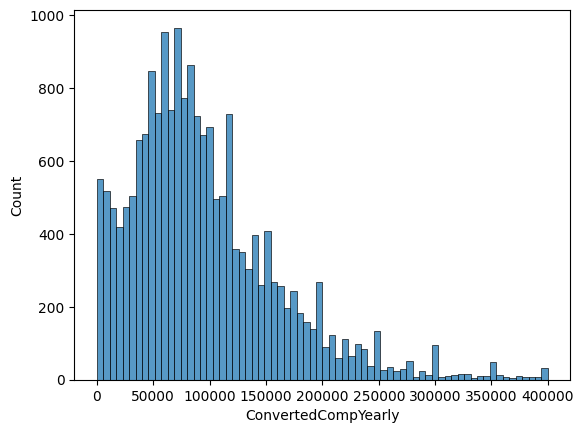

In [522]:
sns.histplot(df_res_pub_final.ConvertedCompYearly)

In [523]:
df_res_pub_final['ConvertedCompYearly'] = df_res_pub_final['ConvertedCompYearly']

In [524]:
# Aplying log transformation in order to treat the skewed curve.
# (log1p(x) = log(1 + x))
df_res_pub_final['ConvertedCompYearly_log'] = np.log1p(df_res_pub_final['ConvertedCompYearly'])

<Axes: xlabel='ConvertedCompYearly_log', ylabel='Count'>

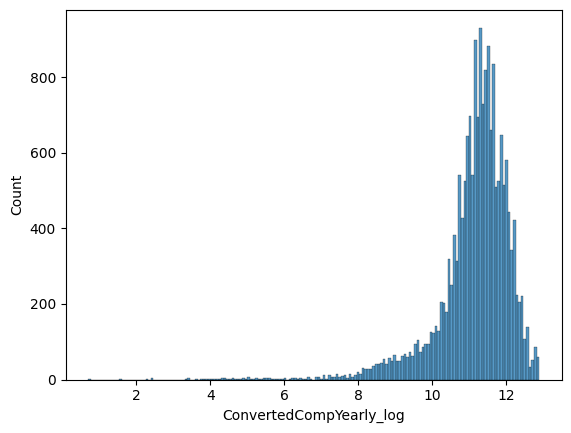

In [525]:
sns.histplot(df_res_pub_final.ConvertedCompYearly_log)

In [526]:
df_res_pub_final.shape

(19110, 568)

# 5 - Splitting and saving the datasets

In [532]:
X = df_res_pub_final.drop('ConvertedCompYearly_log', axis=1)
y = df_res_pub_final[['ConvertedCompYearly_log']]

In [533]:
# Splitting the Dataset
# 1) Train/Test (85%) e Validation (15%)
X_data, X_val, y_data, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42
)


In [534]:
path_df_preprocessed = "preprocessed_data.parquet"
path_X = "X_data.parquet"
path_y = "y_data.parquet"
path_X_val = "X_val.parquet"
path_y_val = "y_val.parquet"

In [535]:
df_res_pub_final.to_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_df_preprocessed}")
X_data.to_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_X}")
y_data.to_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_y}")
X_val.to_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_X_val}")
y_val.to_parquet(f"{LOCAL_PATH}/stackoverflow-udacity-project-course-2/dataset/{path_y_val}")

In [536]:
# y_pred = np.expm1(y_pred_log)